In [106]:
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/impport_packages.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/simulation_class.ipynb"    #import all necessary packages - numpy, pandas etc
%run "////home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/simulation/simulation_prereqs/create_world.ipynb"

#### Setting up environmental parameters

In [124]:
#for epi


folder = Path("/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/phenvar/phenvar_fitnessvar/phenvar_fitnessvar/epi")

epi_obj = {}

for path in folder.glob("*.pkl"):
    print(path)

    # extract dimension from filename
    match = re.search(r"dims(\d+)", path.stem)
    if match:
        dim = int(match.group(1))
        with open(path, "rb") as file:
            results_array_epi = pickle.load(file)
        
        epi_obj[f"epi_{dim}"] = results_array_epi

print(epi_obj.keys())

folder = Path("/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/phenvar/phenvar_fitnessvar/phenvar_fitnessvar/onlygen")

onlygen_obj = {}

for path in folder.glob("*.pkl"):
    print(path)

    match = re.search(r"dims(\d+)", path.stem)
    if match:
        dim = int(match.group(1))
        with open(path, "rb") as file:
            results_array_gen = pickle.load(file)
        
        onlygen_obj[f"gen_{dim}"] = results_array_gen

print(onlygen_obj.keys())

/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/phenvar/phenvar_fitnessvar/phenvar_fitnessvar/epi/rhos30_ms30_gens10000_dims5_mutrate0.001.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/phenvar/phenvar_fitnessvar/phenvar_fitnessvar/epi/rhos30_ms30_gens10000_dims1_mutrate0.001.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/phenvar/phenvar_fitnessvar/phenvar_fitnessvar/epi/rhos30_ms30_gens10000_dims10_mutrate0.001.pkl
dict_keys(['epi_5', 'epi_1', 'epi_10'])
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/phenvar/phenvar_fitnessvar/phenvar_fitnessvar/onlygen/rhos30_ms30_gens10000_dims1_mutrate0.001_onlygen.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/phenvar/phenvar_fitnessvar/phenvar_fitnessvar/onlygen/rhos30_ms30_gens10000_dims5_

In [43]:
rho_cases = 100
m_cases=  100
maxgen= 10000
popsize = 2500
                                 
initial_memory = 0
full_env_values = create_world(rho_cases, m_cases, maxgen)   # create world (input: generations, no. rhos and no. ms) 
print('shape of scenarios with nas:',full_env_values.shape)

clean_data_env = full_env_values[~np.isnan(full_env_values).any(axis=1)]

nof_scenarios = np.shape(clean_data_env)[0]

print('nof examined "worlds" or scenarios:', nof_scenarios) 

gens = np.arange(1, maxgen +1 )
print('number of generations teh simulation is run for', maxgen) 


shape of scenarios with nas: (10000, 10004)
nof examined "worlds" or scenarios: 10000
number of generations teh simulation is run for 10000


In [40]:
epi_obj[f"epi_1"][0].keys()

dict_keys(['maxgen_popsize', 'rho_m_alpha_beta', 'meanw', 'stdw', 'meanmemory_g', 'meanmemory_p', 'meanneutral_g', 'meanneutral_p', 'mean_geno', 'std_phenotype', 'mean_phenotype'])

#### Sanity Check: do the heatmaps look like before?

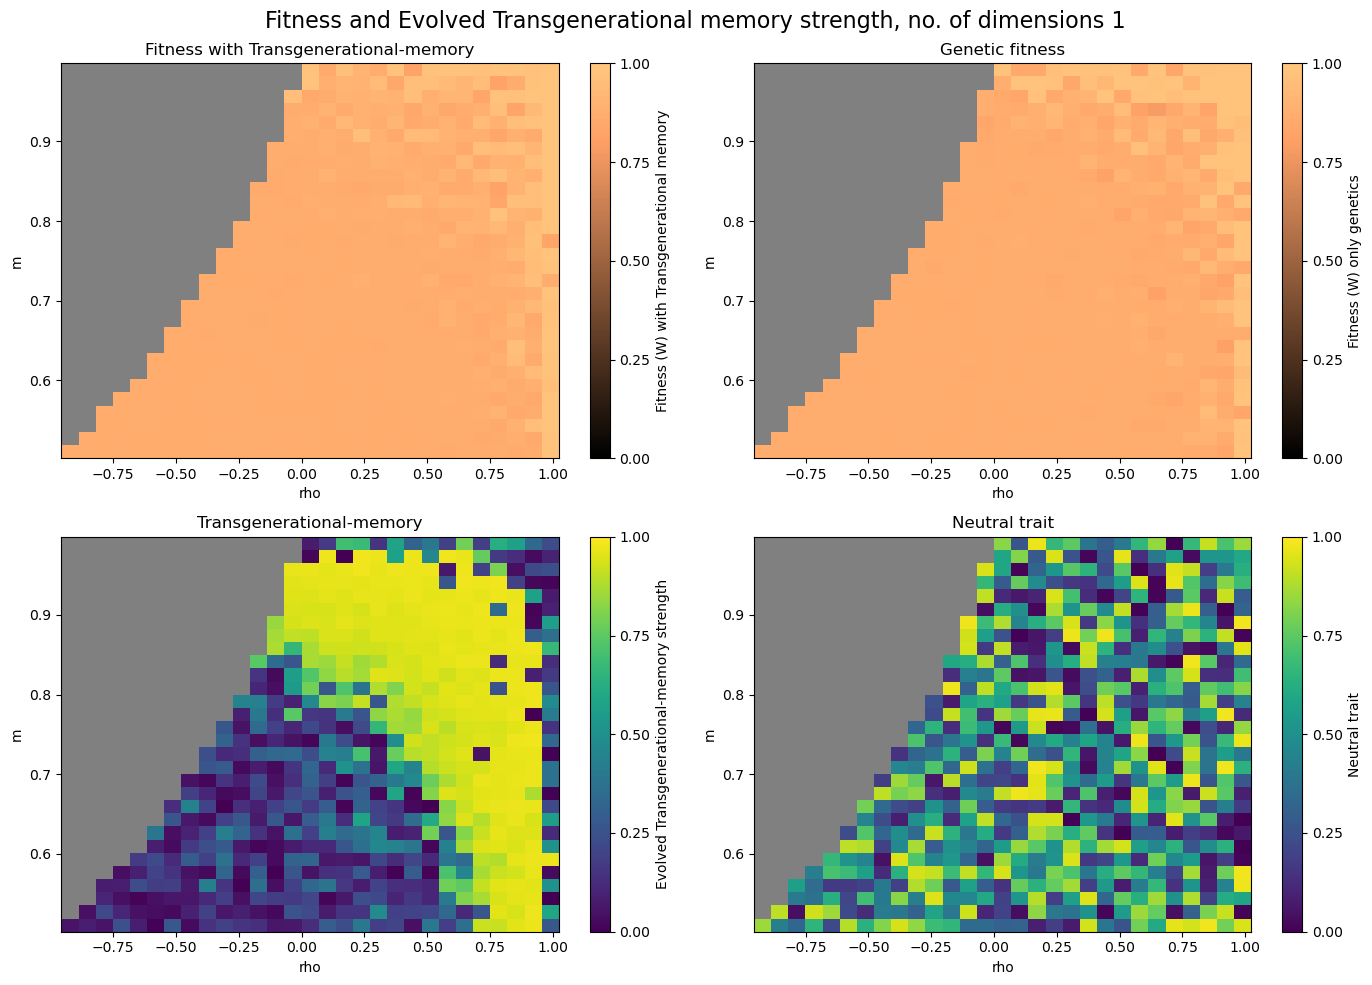

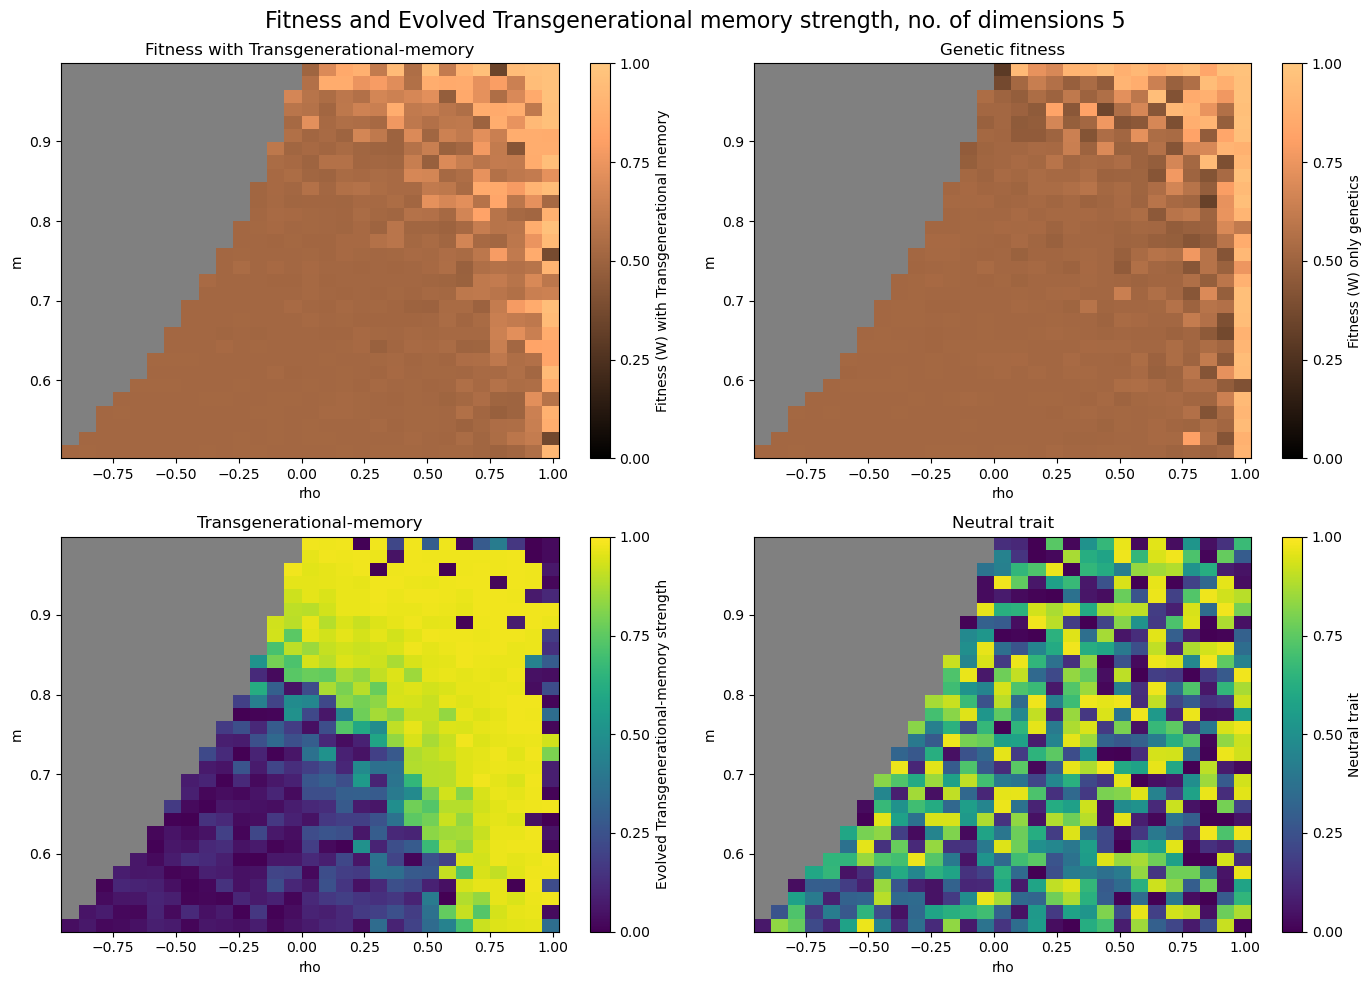

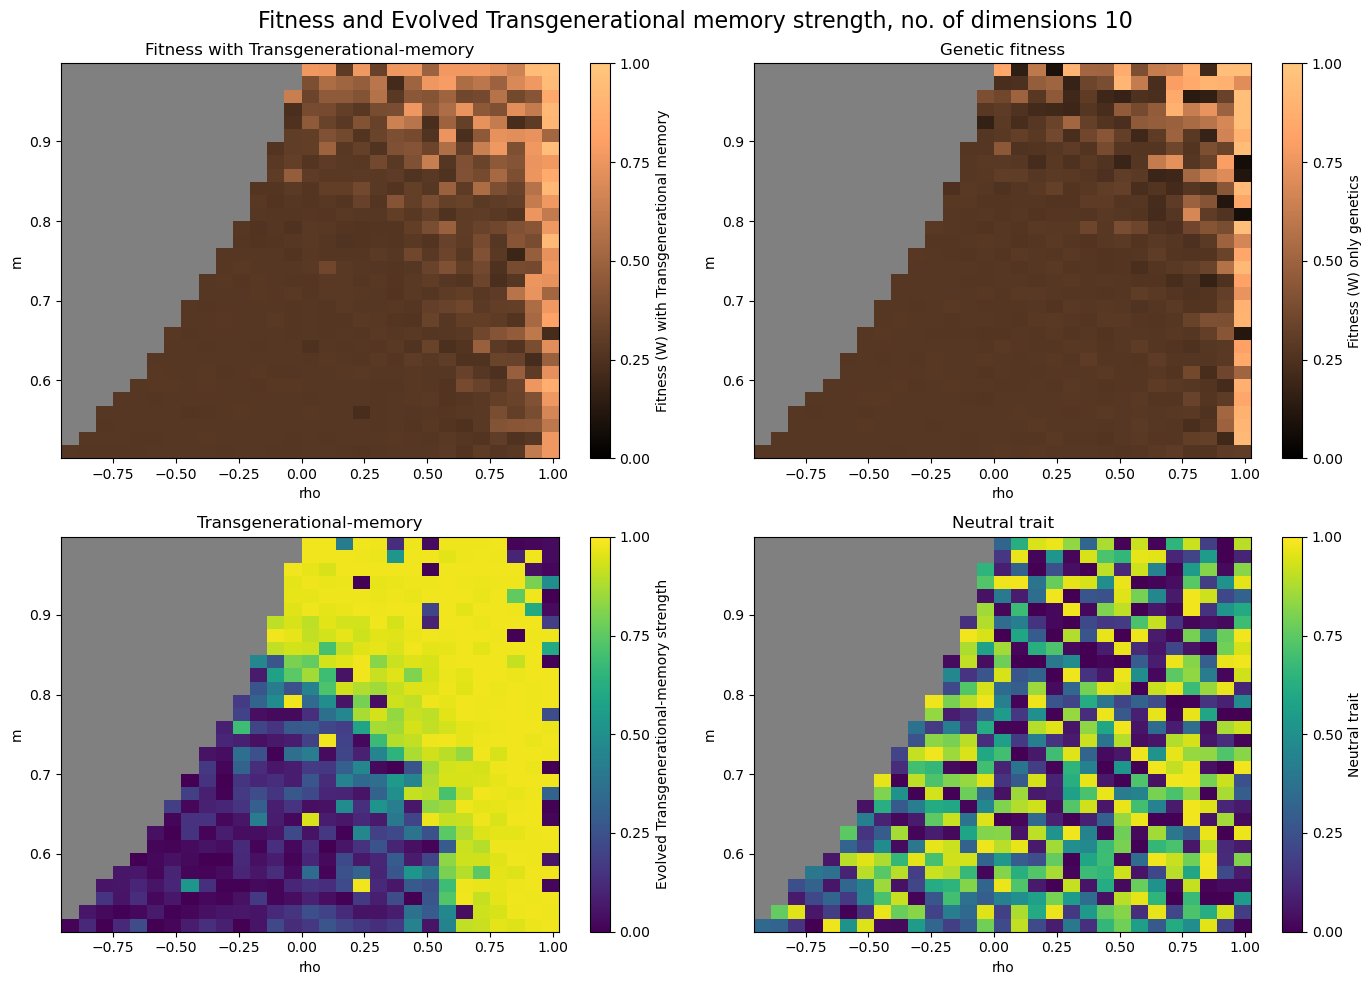

In [44]:
dims=[1,5,10]

for i in dims:

    concat_epi = epi_obj[f"epi_{i}"]
    concat_gen = onlygen_obj[f"gen_{i}"]   # adjust key if needed
    
    keys = list(concat_epi[0].keys())

    concatenated_results_epi = {}
    concatenated_results_gen = {}

    for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
    for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
    df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,-50:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:-100], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:-50], axis=1 ),
    
    })
    
    df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,-50:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:-50], axis=1 )
        })

    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Fitness and Evolved Transgenerational memory strength, no. of dimensions {i}",
        fontsize=16
    )
    
    fig.subplots_adjust(top=0.90)

    cmap1 = plt.cm.copper.copy()
    cmap1.set_bad(color='gray')

    cmap2 = plt.cm.viridis.copy()
    cmap2.set_bad(color='gray')
    
    norm = mcolors.Normalize(vmin=0, vmax=1)
    
    # --- (0,0) fitness ---
    pivoted_fitness = df_epi.pivot_table(
        index='m', columns='rho', values='fitness'
    ).sort_index().sort_index(axis=1)

    pcm1 = ax[0,0].pcolormesh(
        pivoted_fitness.columns,
        pivoted_fitness.index,
        pivoted_fitness.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm1, ax=ax[0,0],
                 label='Fitness (W) with Transgenerational memory',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[0,0].set_title(r'Fitness with Transgenerational-memory')
    ax[0,0].set_ylabel('m')
    ax[0,0].set_xlabel('rho')

    # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
        index='m', columns='rho', values='fitness'
    ).sort_index().sort_index(axis=1)

    pcm2 = ax[0,1].pcolormesh(
        pivoted_gen.columns,
        pivoted_gen.index,
        pivoted_gen.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm2, ax=ax[0,1],
                 label='Fitness (W) only genetics',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[0,1].set_title('Genetic fitness')
    ax[0,1].set_ylabel('m')
    ax[0,1].set_xlabel('rho')

    # --- (1,0) epimem ---
    pivoted_epi = df_epi.pivot_table(
        index='m', columns='rho', values='epi_mem_p'
    ).sort_index().sort_index(axis=1)

    pcm3 = ax[1,0].pcolormesh(
        pivoted_epi.columns,
        pivoted_epi.index,
        pivoted_epi.values,
        cmap=cmap2, norm=norm, shading='auto'
    )
    fig.colorbar(pcm3, ax=ax[1,0],
                 label='Evolved Transgenerational-memory strength',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[1,0].set_title('Transgenerational-memory')
    ax[1,0].set_ylabel('m')
    ax[1,0].set_xlabel('rho')

    # --- (1,1) neutral ---
    pivoted_neutral = df_epi.pivot_table(
        index='m', columns='rho', values='neutral_trait_p'
    ).sort_index().sort_index(axis=1)

    pcm4 = ax[1,1].pcolormesh(
        pivoted_neutral.columns,
        pivoted_neutral.index,
        pivoted_neutral.values,
        cmap=cmap2, norm=norm, shading='auto'
    )
    fig.colorbar(pcm4, ax=ax[1,1],
                 label='Neutral trait',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[1,1].set_title('Neutral trait')
    ax[1,1].set_ylabel('m')
    ax[1,1].set_xlabel('rho')

    plt.tight_layout()
    plt.show()



#### Standard deviation in mean fitness: averaged across all generations

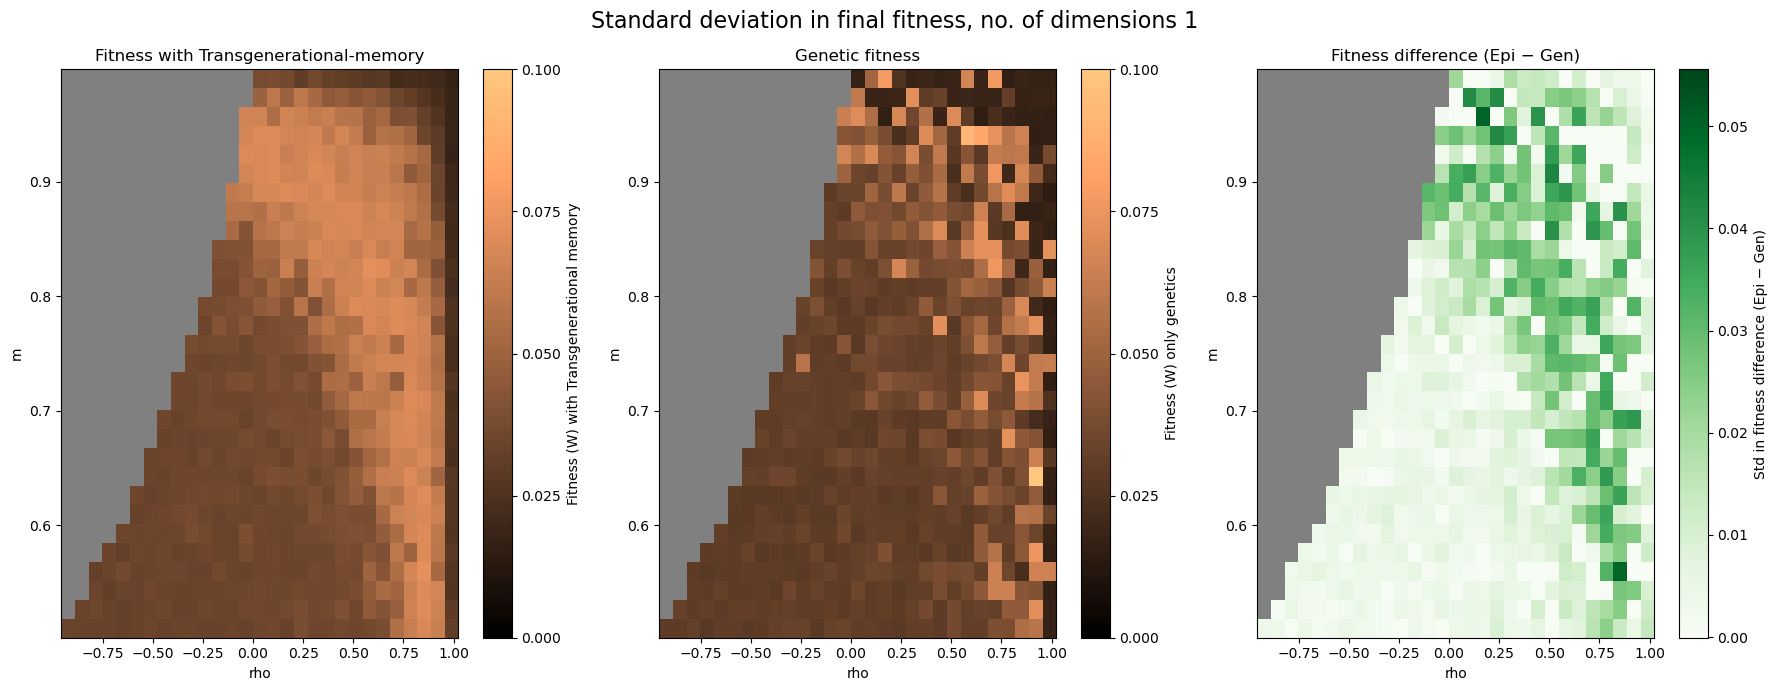

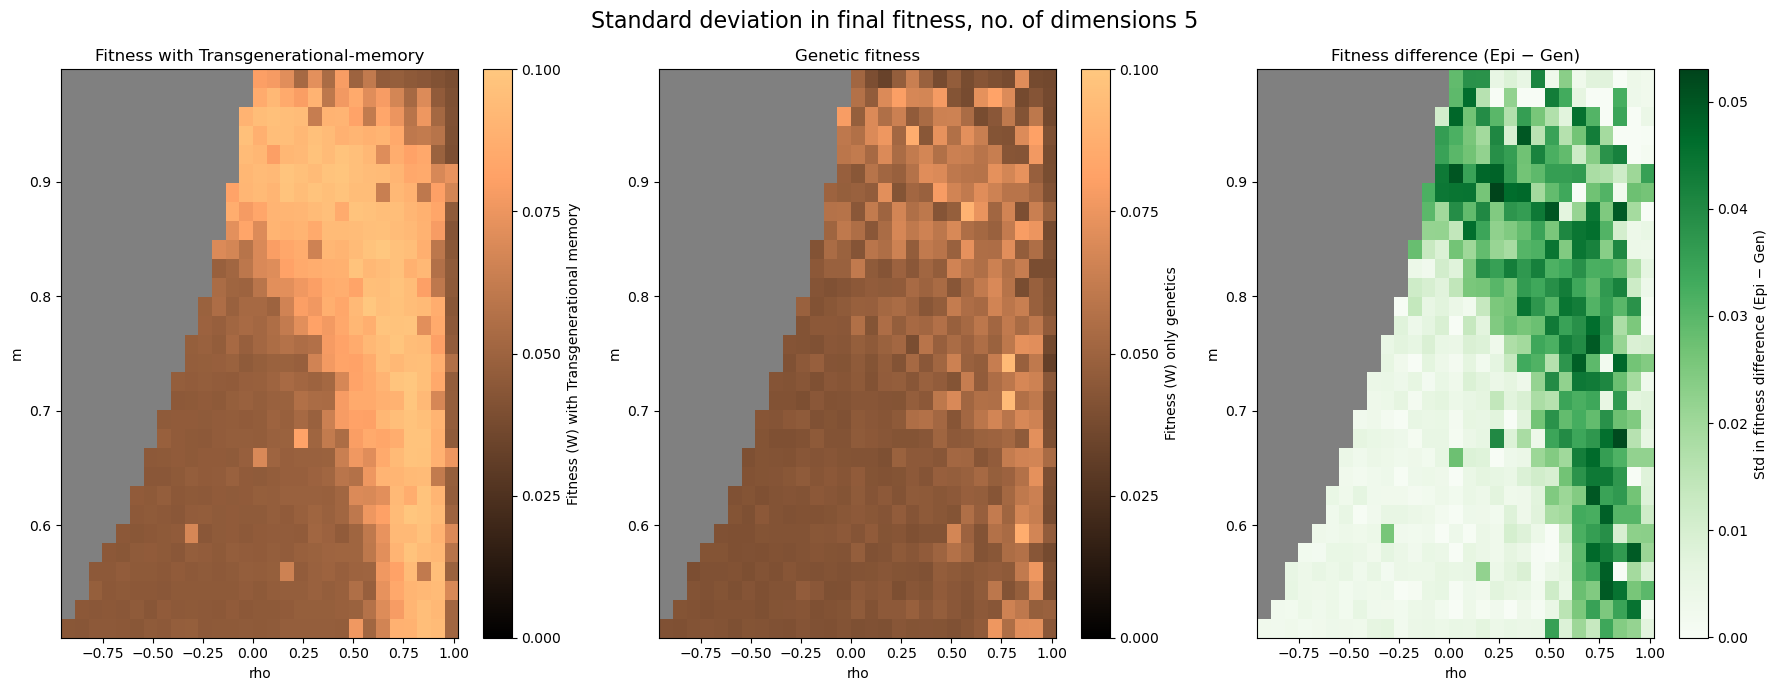

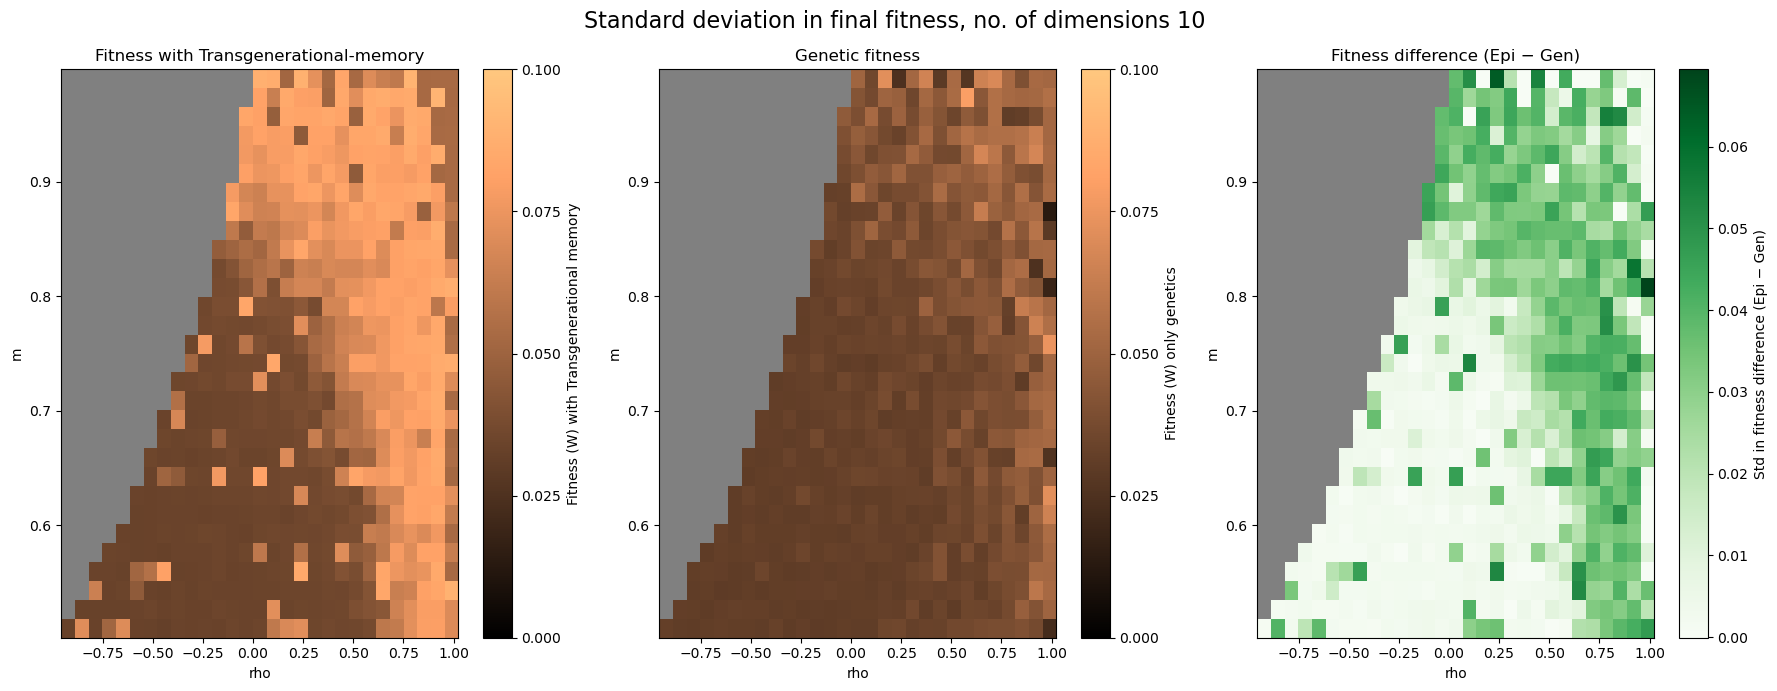

In [103]:


for i in dims:

    concat_epi = epi_obj[f"epi_{i}"]
    concat_gen = onlygen_obj[f"gen_{i}"]   # adjust key if needed
    
    keys = list(concat_epi[0].keys())

    concatenated_results_epi = {}
    concatenated_results_gen = {}

    for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
    for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
    df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:-50], axis=1 ),
    
    })
    
    df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,-50:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:-50], axis=1 )
        })

    fig, ax = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(
        f"Standard deviation in final fitness, no. of dimensions {i}",
        fontsize=16
    )
    
    fig.subplots_adjust(top=0.90)

    cmap1 = plt.cm.copper.copy()
    cmap1.set_bad(color='gray')

    cmap2 = plt.cm.viridis.copy()
    cmap2.set_bad(color='gray')

    # --- (0,0) fitness ---
    pivoted_fitness = df_epi.pivot_table(
        index='m', columns='rho', values='stdw'
    ).sort_index().sort_index(axis=1)
    
    max_abs = np.nanmax(np.abs(pivoted_fitness.values))
    min_abs = np.nanmin(np.abs(pivoted_fitness.values))
    
    norm = mcolors.Normalize(vmin=0, vmax=0.1)
    
    pcm1 = ax[0].pcolormesh(
        pivoted_fitness.columns,
        pivoted_fitness.index,
        pivoted_fitness.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm1, ax=ax[0],
                 label='Fitness (W) with Transgenerational memory',
                 ticks=[0,0.025,0.05, 0.075,0.1])

    ax[0].set_title(r'Fitness with Transgenerational-memory')
    ax[0].set_ylabel('m')
    ax[0].set_xlabel('rho')

    # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
        index='m', columns='rho', values='stdw'
    ).sort_index().sort_index(axis=1)

    max_abs = np.nanmax(np.abs(pivoted_fitness.values))
    min_abs = np.nanmin(np.abs(pivoted_fitness.values))
        
    norm = mcolors.Normalize(vmin=0, vmax=0.1)
    
    pcm2 = ax[1].pcolormesh(
        pivoted_gen.columns,
        pivoted_gen.index,
        pivoted_gen.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm2, ax=ax[1],
                 label='Fitness (W) only genetics',
                 ticks=[0,0.025,0.05, 0.075,0.1])

    ax[1].set_title('Genetic fitness')
    ax[1].set_ylabel('m')
    ax[1].set_xlabel('rho')
    
    #-----------
    #Epi std - genstd
    #------------
    pivoted_fitness_subtracted = pivoted_fitness - pivoted_gen
    # symmetric normalization around 0
    max_abs = np.nanmax(np.abs(pivoted_fitness_subtracted.values))
    min_abs = np.nanmin(np.abs(pivoted_fitness_subtracted.values))
    
    cmap_diff = plt.cm.Greens.copy()
    cmap_diff.set_bad(color='gray')
    norm_diff = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)

    pcm_diff = ax[2].pcolormesh(
        pivoted_fitness_subtracted.columns,
        pivoted_fitness_subtracted.index,
        pivoted_fitness_subtracted.values,
        cmap=cmap_diff,   # diverging colormap
        norm=norm_diff,
        shading='auto'
    )

    fig.colorbar(
        pcm_diff,
        ax=ax[2],
        label='Std in fitness difference (Epi − Gen)'
    )
    
    ax[2].set_title('Fitness difference (Epi − Gen)')
    ax[2].set_ylabel('m')
    ax[2].set_xlabel('rho')

    plt.tight_layout()
    plt.show()


#### Standard deviation in fitness across Dimensions: does it increase or decrease with increasing dimensions

Expectation: dimensionality decreases variance in fitness; presence of Transgenerational-memory allows the population to 'remember' environmental variation: so should increase variance in fitness

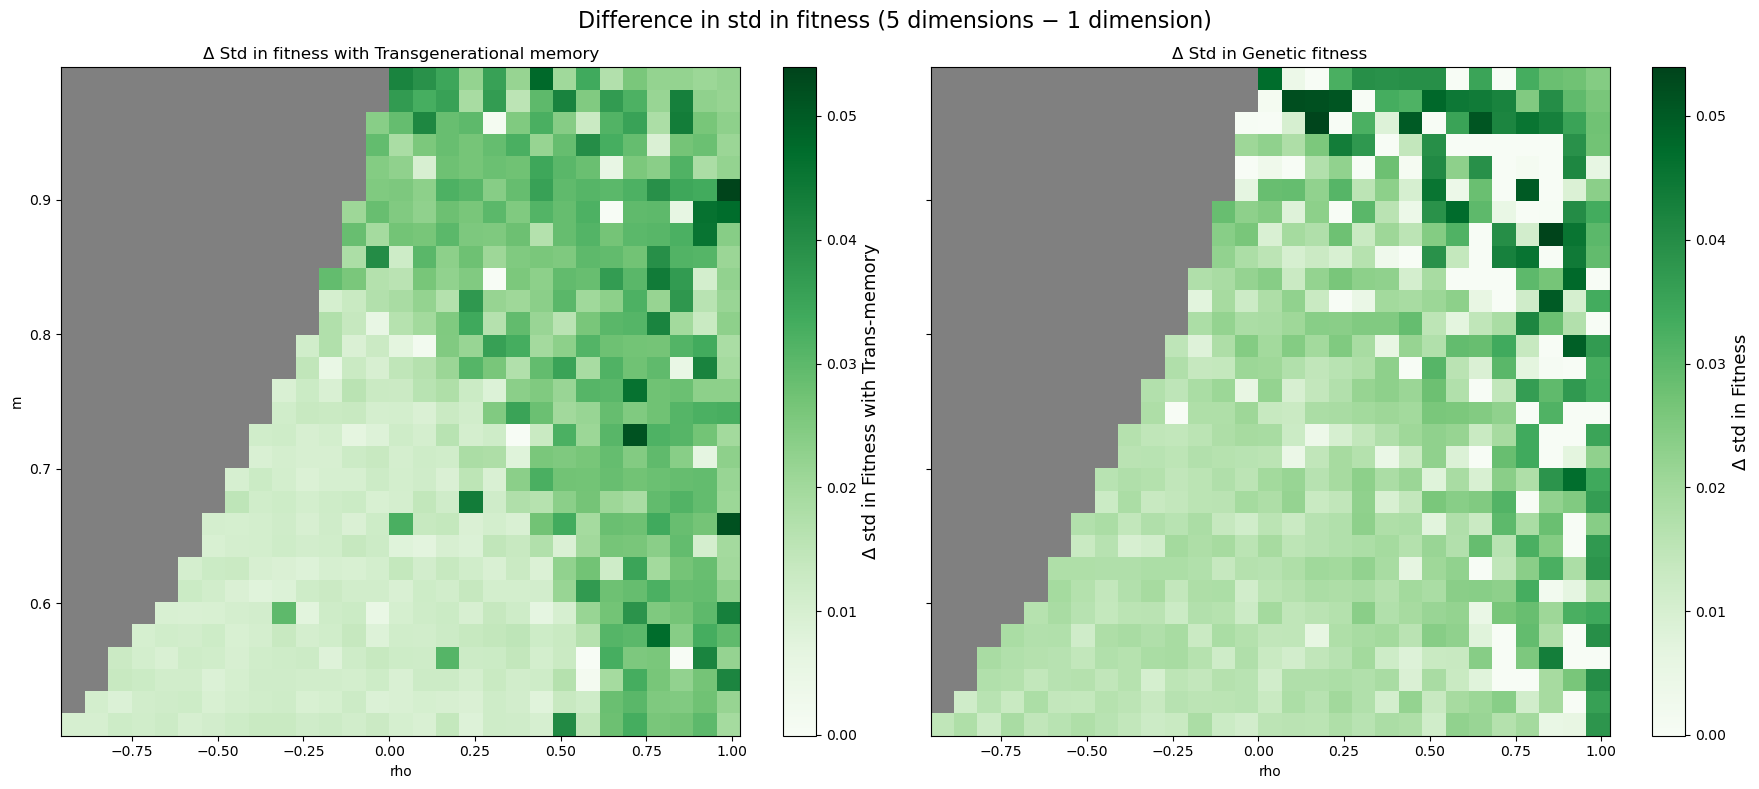

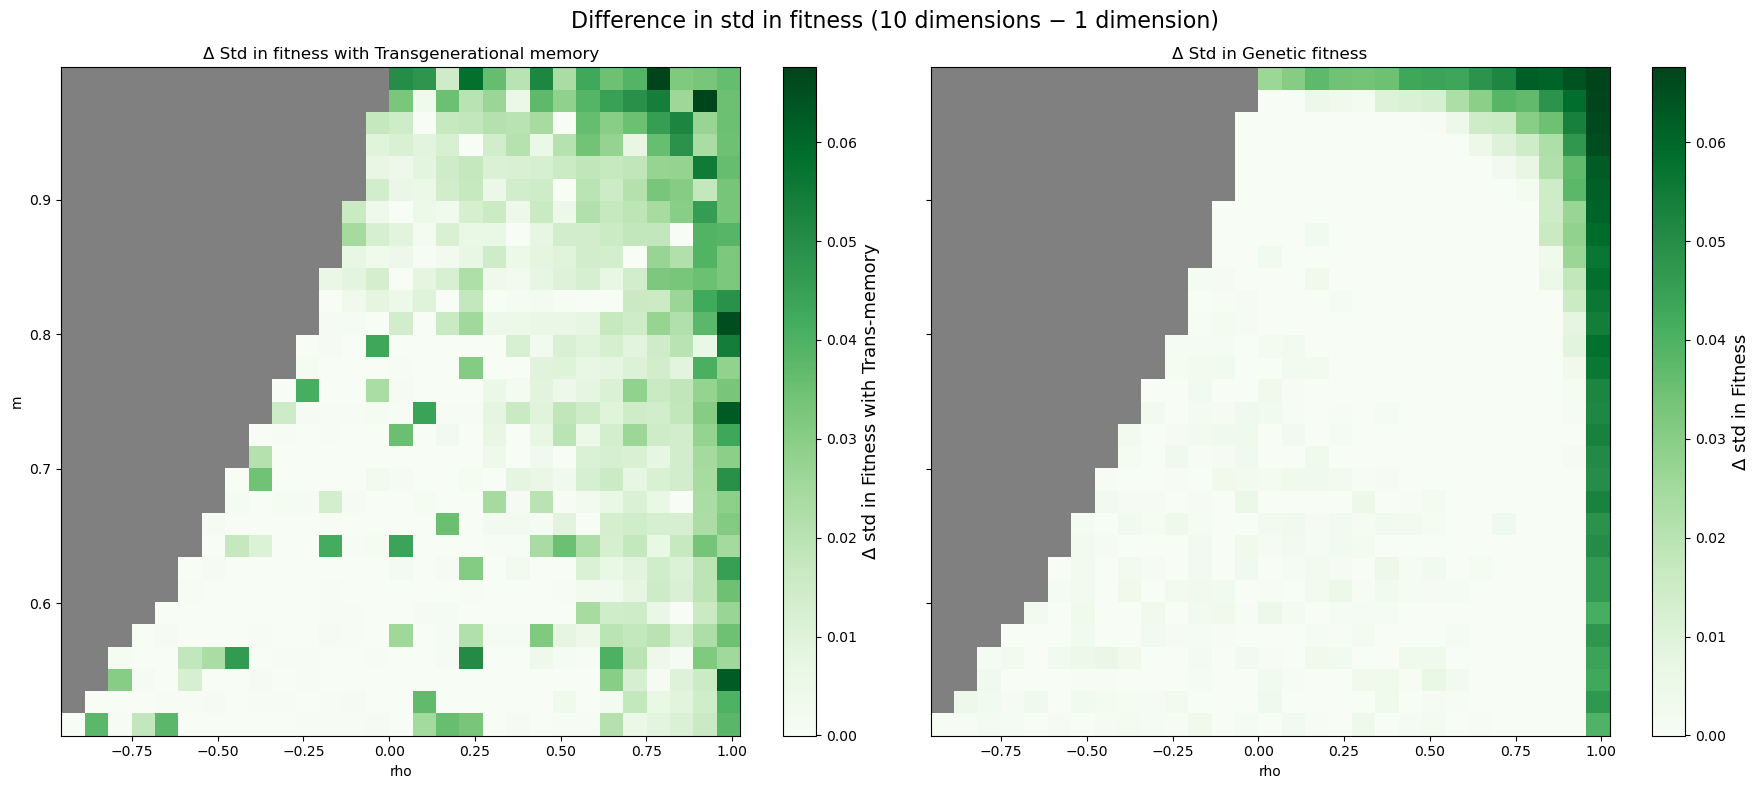

In [ ]:
#---------
# dims 5-1
#----------

base_dim = 1        # reference
compare_dim = 5  


fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)
fig.suptitle(
    f"Difference in std in fitness ({compare_dim} dimensions − {base_dim} dimension)",
    fontsize=16
)
fig.subplots_adjust(top=0.90)

# colormap for difference
cmap = plt.cm.Greens.copy()
cmap.set_bad(color='gray')



# ---------- LOAD DATA ----------
#base dim
concat_epi = epi_obj[f"epi_{base_dim}"]
concat_gen = onlygen_obj[f"gen_{base_dim}"]   
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:-50], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,-50:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:-50], axis=1 )
        })

pivoted_epi_base = (
    df_epi
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)

pivot_genetic_base = (
    df_gen
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)


#Compared dim

concat_epi = epi_obj[f"epi_{compare_dim}"]
concat_gen = onlygen_obj[f"gen_{compare_dim}"]   # adjust key if needed
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:-50], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:-50], axis=1 )
        })



pivoted_epi_comp = (
    df_epi
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)


pivot_genetic_comp = (
    df_gen
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- DIFFERENCES ----------
delta_mem_fitness = pivoted_epi_comp - pivoted_epi_base
delta_genetic_fitness = pivot_genetic_comp - pivot_genetic_base

# symmetric normalization around 0
# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_mem_fitness.values))
min_abs = np.nanmin(np.abs(delta_mem_fitness.values))
    
norm_diff_1 = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)

# ---------- PLOTS ----------
pcm0 = axes[0].pcolormesh(
    delta_mem_fitness.columns,
    delta_mem_fitness.index,
    delta_mem_fitness.values,
    cmap=cmap,
    norm=norm_diff_1,
    shading='auto'
)
axes[0].set_title("Δ Std in fitness with Transgenerational memory")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("m")

cbar = fig.colorbar(
    pcm0,
    ax=axes[0],
)
cbar.set_label('Δ std in Fitness with Trans-memory', fontsize=13)

# symmetric normalization around 0
# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_genetic_fitness.values))
min_abs = np.nanmin(np.abs(delta_genetic_fitness.values))
    
norm_diff_2 = mcolors.Normalize(vmin=-min_abs,  vmax=max_abs)

pcm1 = axes[1].pcolormesh(
    delta_genetic_fitness.columns,
    delta_genetic_fitness.index,
    delta_genetic_fitness.values,
    cmap=cmap,
    norm=norm_diff_2,
    shading='auto'
)
axes[1].set_title("Δ Std in Genetic fitness")
axes[1].set_xlabel("rho")

# ---------- COLORBAR ----------
cbar = fig.colorbar(
    pcm0,
    ax=axes[1],
)
cbar.set_label('Δ std in Fitness', fontsize=13)
plt.tight_layout()
plt.show()


#------------
# 10-1
#-------------

base_dim = 1        # reference
compare_dim = 10  


fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)
fig.suptitle(
    f"Difference in std in fitness ({compare_dim} dimensions − {base_dim} dimension)",
    fontsize=16
)
fig.subplots_adjust(top=0.90)


# ---------- LOAD DATA ----------
#base dim
concat_epi = epi_obj[f"epi_{base_dim}"]
concat_gen = onlygen_obj[f"gen_{base_dim}"]   
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:-50], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['memin_absan_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:-50], axis=1 )
        })

pivoted_epi_base = (
    df_epi
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)

pivot_genetic_base = (
    df_gen
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)


#Compared dim

concat_epi = epi_obj[f"epi_{compare_dim}"]
concat_gen = onlygen_obj[f"gen_{compare_dim}"]   # adjust key if needed
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:-50], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:-50], axis=1 )
        })



pivoted_epi_comp = (
    df_epi
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)


pivot_genetic_comp = (
    df_gen
    .pivot_table(index='m', columns='rho', values='stdw')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- DIFFERENCES ----------
delta_mem_fitness = pivoted_epi_comp - pivoted_epi_base
delta_genetic_fitness = pivot_genetic_comp - pivot_genetic_base

# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_mem_fitness.values))
min_abs = np.nanmin(np.abs(delta_mem_fitness.values))
    
norm_diff_1 = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)


# ---------- PLOTS ----------
pcm0 = axes[0].pcolormesh(
    delta_mem_fitness.columns,
    delta_mem_fitness.index,
    delta_mem_fitness.values,
    cmap=cmap,
    norm=norm_diff_1,
    shading='auto'
)
axes[0].set_title("Δ Std in fitness with Transgenerational memory")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("m")

cbar = fig.colorbar(
    pcm0,
    ax=axes[0],
)
cbar.set_label('Δ std in Fitness with Trans-memory', fontsize=13)

# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_genetic_fitness.values))
min_abs = np.nanmin(np.abs(delta_genetic_fitness.values))
    
norm_diff_2 = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)

pcm1 = axes[1].pcolormesh(
    delta_genetic_fitness.columns,
    delta_genetic_fitness.index,
    delta_genetic_fitness.values,
    cmap=cmap,
    norm=norm_diff_2,
    shading='auto'
)
axes[1].set_title("Δ Std in Genetic fitness")
axes[1].set_xlabel("rho")

# ---------- COLORBAR ----------
cbar = fig.colorbar(
    pcm0,
    ax=axes[1],
)
cbar.set_label('Δ std in Fitness', fontsize=13)
plt.tight_layout()
plt.show()





#### Standard deviation in phenotype : Averaged across all generations

Expectation: transgenerational memory should increase phenotypic variation

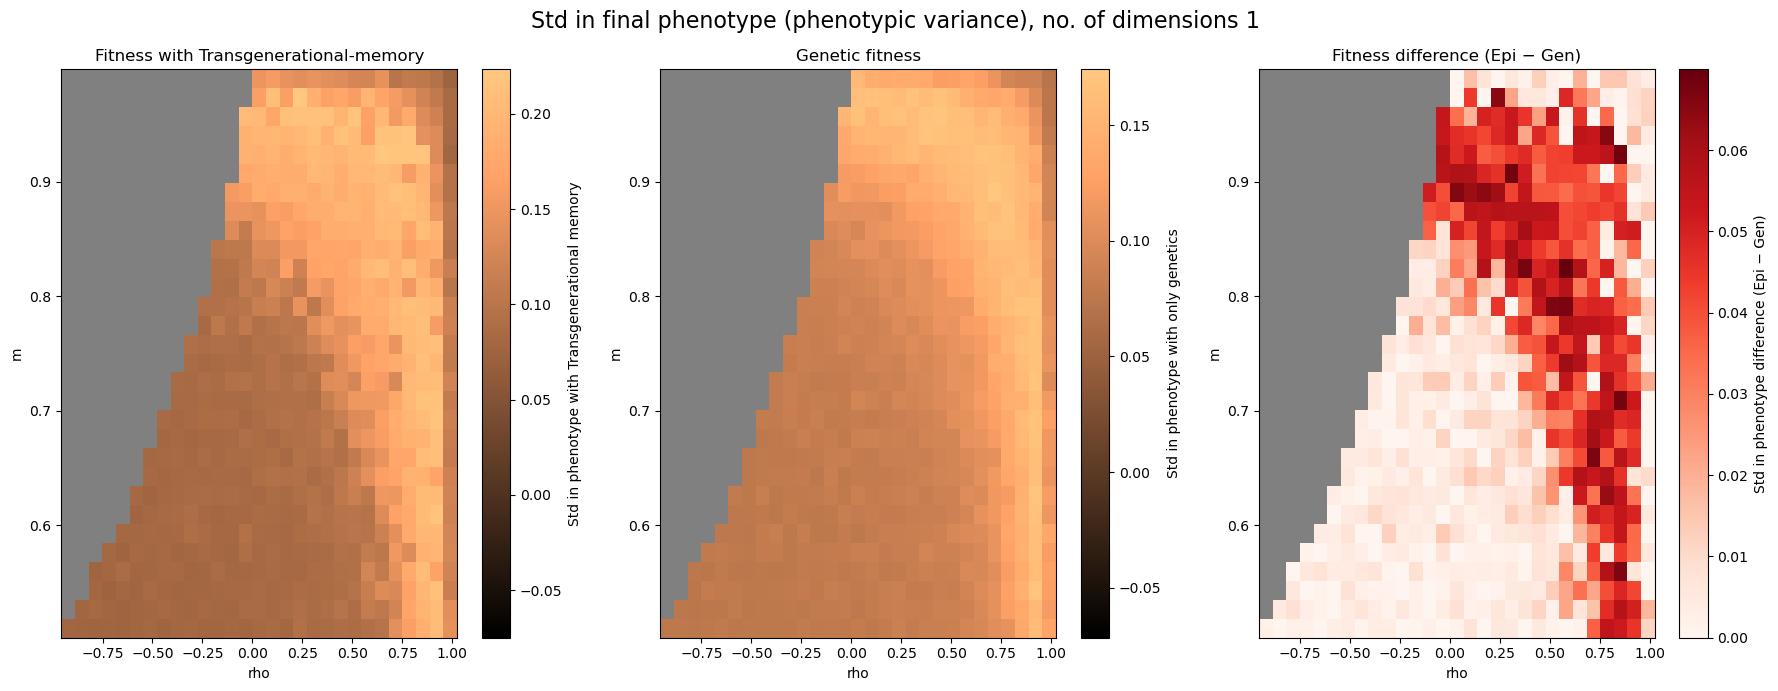

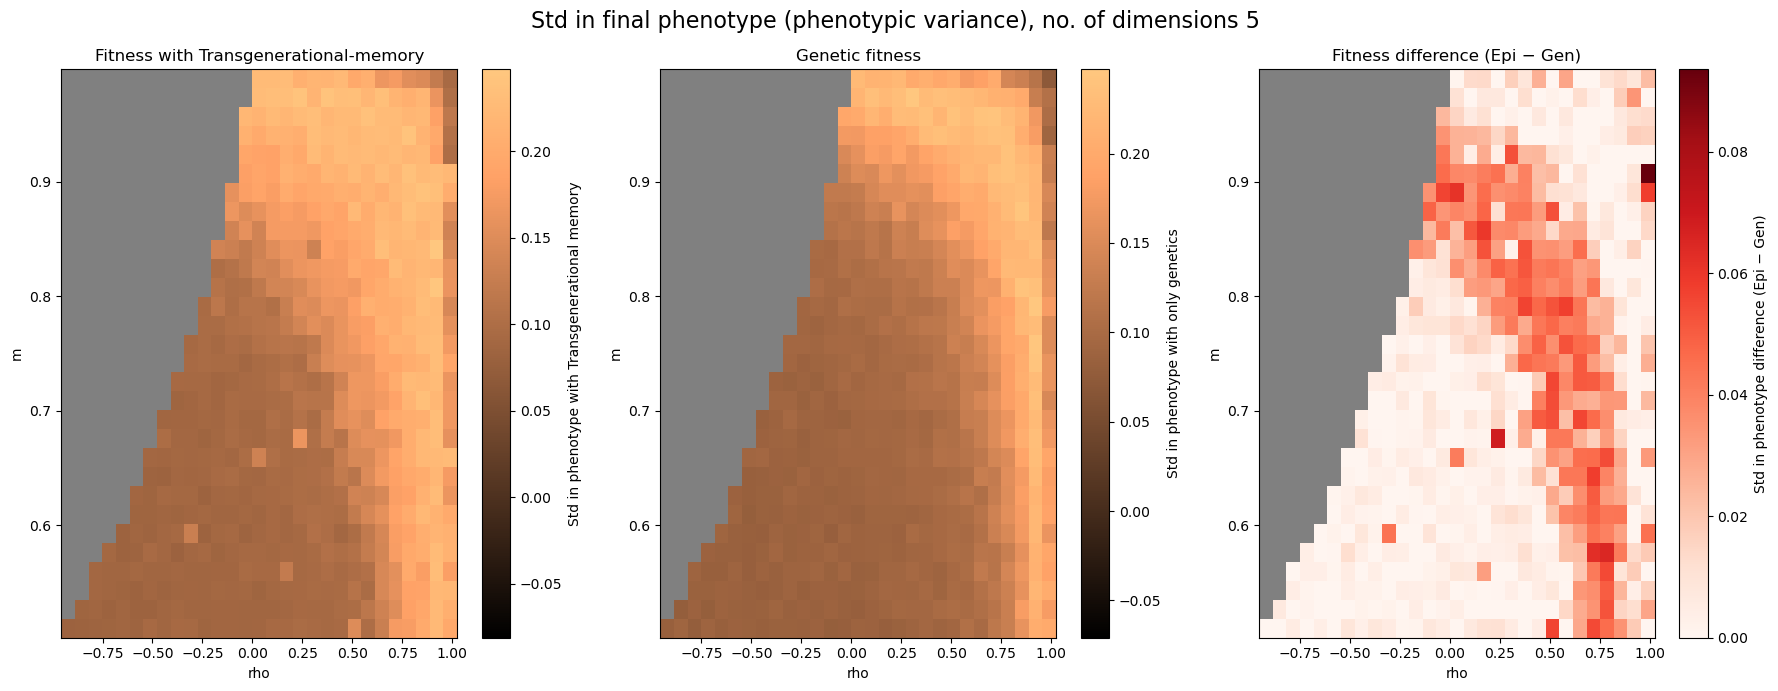

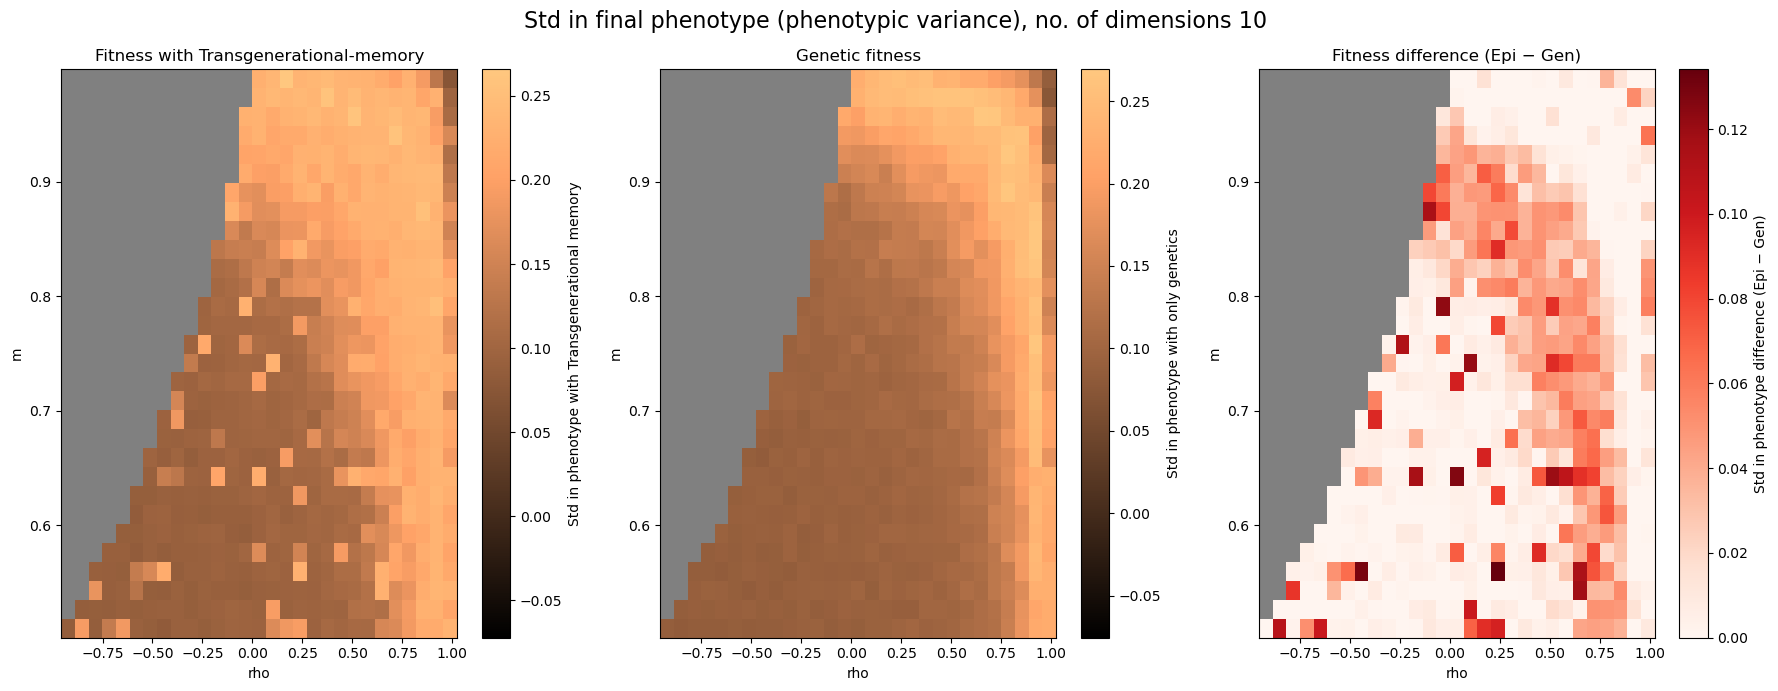

In [105]:
dims=[1,5,10]

for i in dims:

    concat_epi = epi_obj[f"epi_{i}"]
    concat_gen = onlygen_obj[f"gen_{i}"]   # adjust key if needed
    
    keys = list(concat_epi[0].keys())

    concatenated_results_epi = {}
    concatenated_results_gen = {}

    for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
    for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
    df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,-50:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:], axis=1 ),
    
    })
    
    df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:], axis=1 )
        })

    fig, ax = plt.subplots(1, 3, figsize=(18, 7))
    fig.suptitle(
        f"Std in final phenotype (phenotypic variance), no. of dimensions {i}",
        fontsize=16
    )
    
    fig.subplots_adjust(top=0.90)

    cmap1 = plt.cm.copper.copy()
    cmap1.set_bad(color='gray')

    cmap2 = plt.cm.viridis.copy()
    cmap2.set_bad(color='gray')

    # --- (0,0) fitness ---
    pivoted_fitness = df_epi.pivot_table(
        index='m', columns='rho', values='std_phenotype'
    ).sort_index().sort_index(axis=1)
    
    max_abs = np.nanmax(np.abs(pivoted_fitness.values))
    min_abs = np.nanmin(np.abs(pivoted_fitness.values))
    
    norm = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)
    
    pcm1 = ax[0].pcolormesh(
        pivoted_fitness.columns,
        pivoted_fitness.index,
        pivoted_fitness.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm1, ax=ax[0],
                 label='Std in phenotype with Transgenerational memory')

    ax[0].set_title(r'Fitness with Transgenerational-memory')
    ax[0].set_ylabel('m')
    ax[0].set_xlabel('rho')

    # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
        index='m', columns='rho', values='std_phenotype'
    ).sort_index().sort_index(axis=1)

    max_abs = np.nanmax(np.abs(pivoted_gen.values))
    min_abs = np.nanmin(np.abs(pivoted_gen.values))
    
    norm = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)
    
    pcm2 = ax[1].pcolormesh(
        pivoted_gen.columns,
        pivoted_gen.index,
        pivoted_gen.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm2, ax=ax[1],
                 label='Std in phenotype with only genetics')

    ax[1].set_title('Genetic fitness')
    ax[1].set_ylabel('m')
    ax[1].set_xlabel('rho')
    
    #-----------
    #Epi std - genstd
    #------------
    pivoted_fitness_subtracted = pivoted_fitness - pivoted_gen
    
    # symmetric normalization around 0
    max_abs = np.nanmax(np.abs(pivoted_fitness_subtracted.values))
    min_abs = np.nanmin(np.abs(pivoted_fitness_subtracted.values))
    cmap_diff = plt.cm.Reds.copy()  # copy to modify safely
    cmap_diff.set_bad(color='gray') 
    norm_diff = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)

    pcm_diff = ax[2].pcolormesh(
        pivoted_fitness_subtracted.columns,
        pivoted_fitness_subtracted.index,
        pivoted_fitness_subtracted.values,
        cmap=cmap_diff,   # diverging colormap
        norm=norm_diff,
        shading='auto'
    )

    fig.colorbar(
        pcm_diff,
        ax=ax[2],
        label='Std in phenotype difference (Epi − Gen)'
    )
    
    ax[2].set_title('Fitness difference (Epi − Gen)')
    ax[2].set_ylabel('m')
    ax[2].set_xlabel('rho')


    plt.tight_layout()
    plt.show()



Stable environments result in higher phenotypic variation. 

#### Standard deviation in phenotype across Dimensions: does it increase or decrease with increasing dimensions

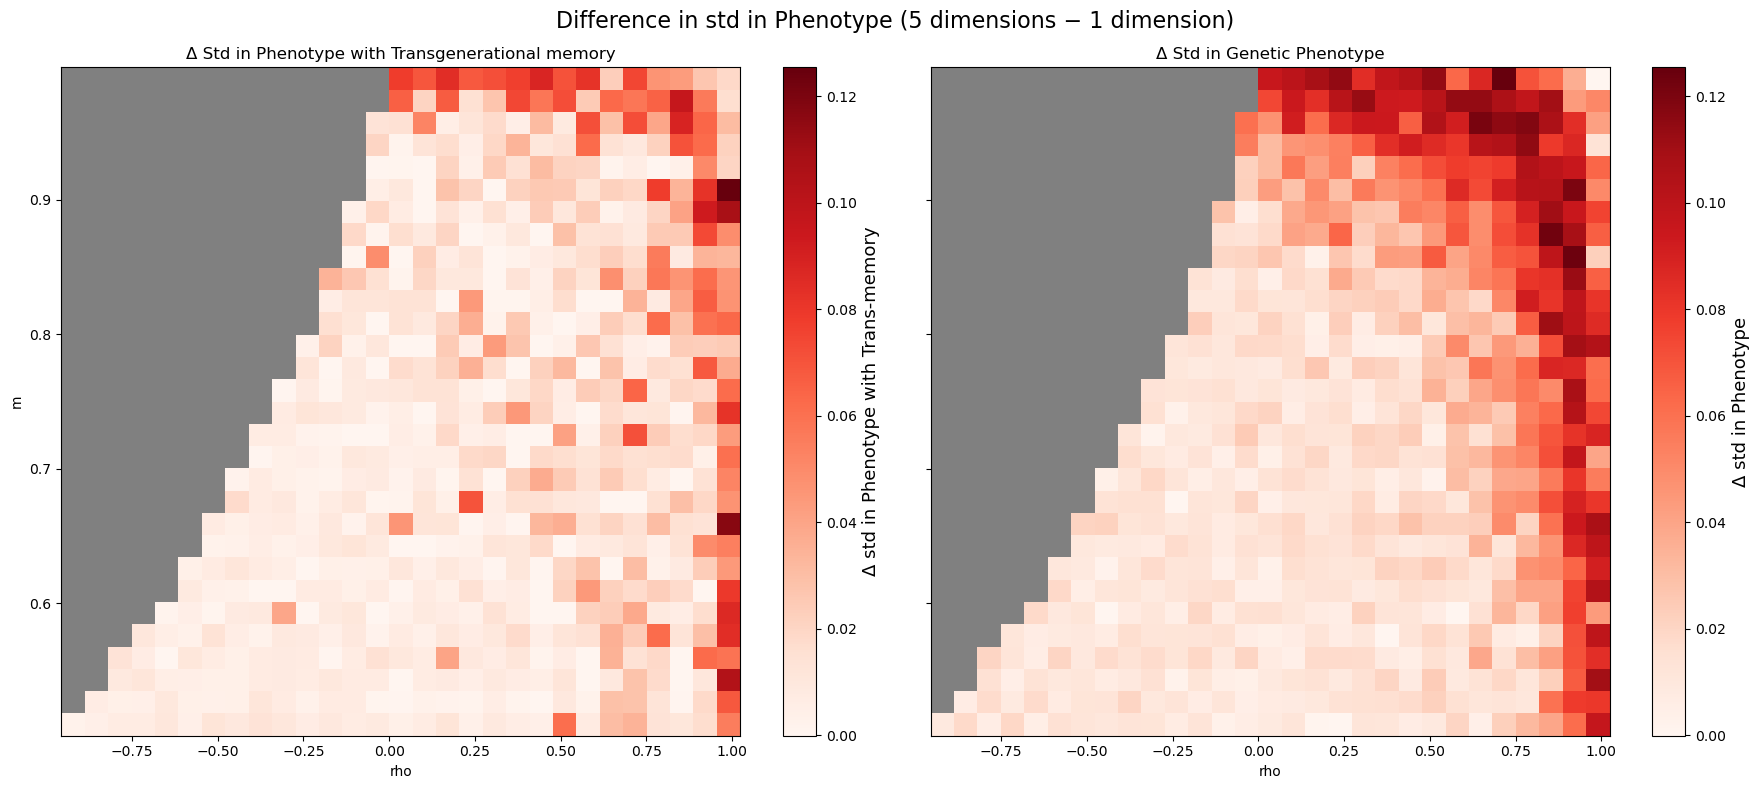

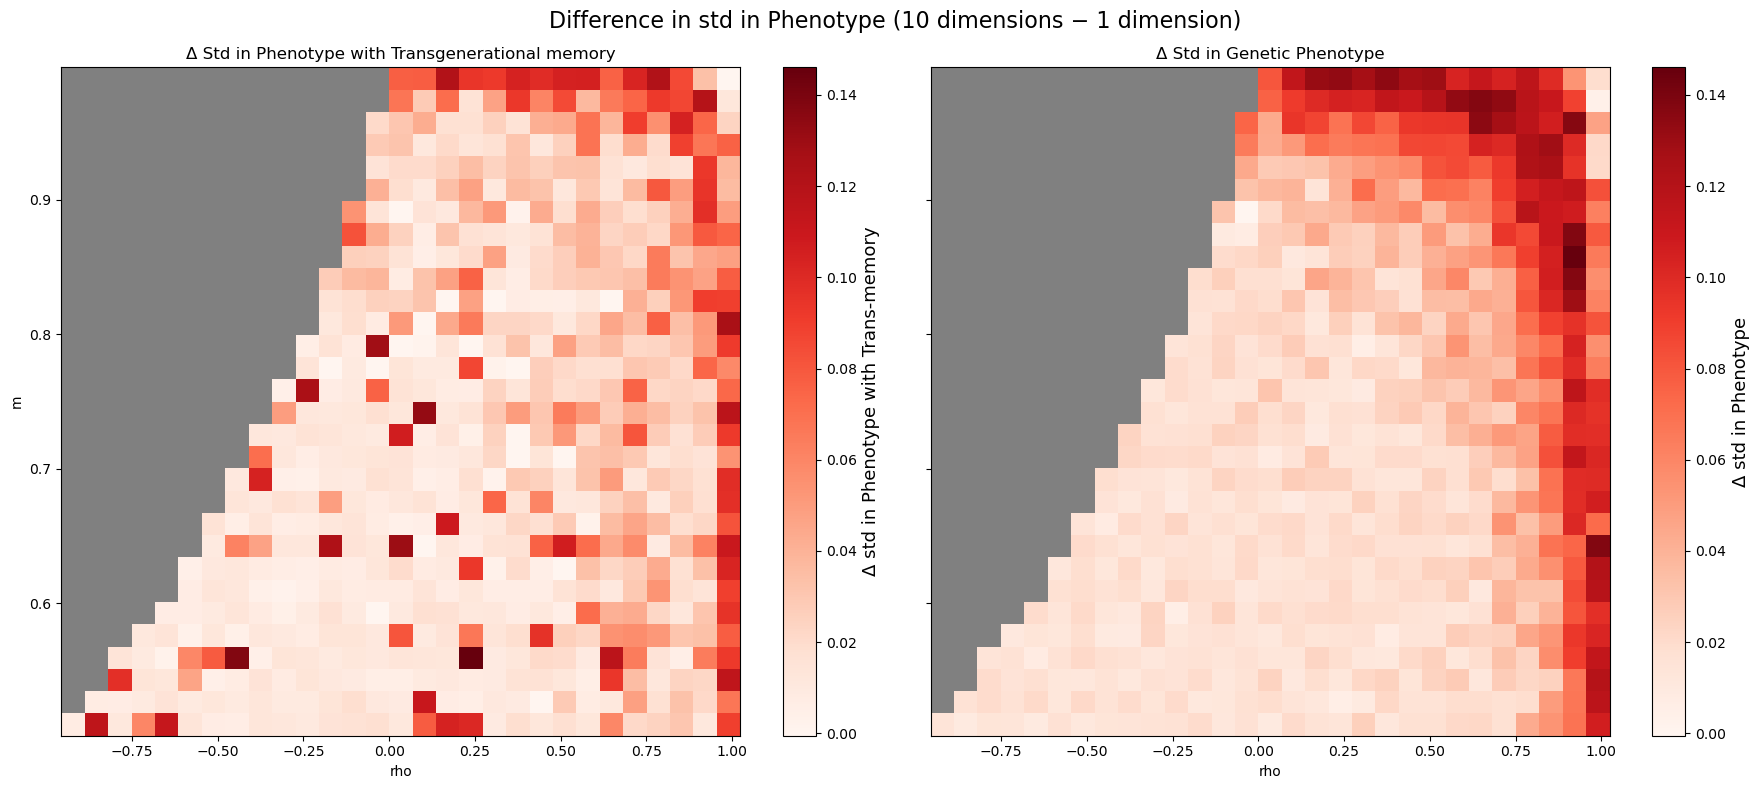

In [116]:
#---------
# dims 5-1
#----------

base_dim = 1        # reference
compare_dim = 5  


fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)
fig.suptitle(
    f"Difference in std in Phenotype ({compare_dim} dimensions − {base_dim} dimension)",
    fontsize=16
)
fig.subplots_adjust(top=0.90)

# colormap for difference
cmap = plt.cm.Reds.copy()
cmap.set_bad(color='gray')



# ---------- LOAD DATA ----------
#base dim
concat_epi = epi_obj[f"epi_{base_dim}"]
concat_gen = onlygen_obj[f"gen_{base_dim}"]   
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,-50:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:], axis=1 )
        })

pivoted_epi_base = (
    df_epi
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)

pivot_genetic_base = (
    df_gen
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)


#Compared dim

concat_epi = epi_obj[f"epi_{compare_dim}"]
concat_gen = onlygen_obj[f"gen_{compare_dim}"]   # adjust key if needed
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:], axis=1 )
        })



pivoted_epi_comp = (
    df_epi
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)


pivot_genetic_comp = (
    df_gen
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- DIFFERENCES ----------
delta_mem_phenotype_std = pivoted_epi_comp - pivoted_epi_base
delta_genetic_phenotype_std  = pivot_genetic_comp - pivot_genetic_base

# symmetric normalization around 0
# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_mem_phenotype_std.values))
min_abs = np.nanmin(np.abs(delta_mem_phenotype_std.values))
    
norm_diff_1 = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)

# ---------- PLOTS ----------
pcm0 = axes[0].pcolormesh(
    delta_mem_phenotype_std.columns,
    delta_mem_phenotype_std.index,
    delta_mem_phenotype_std.values,
    cmap=cmap,
    norm=norm_diff_1,
    shading='auto'
)
axes[0].set_title("Δ Std in Phenotype with Transgenerational memory")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("m")

cbar = fig.colorbar(
    pcm0,
    ax=axes[0],
)
cbar.set_label('Δ std in Phenotype with Trans-memory', fontsize=13)

# symmetric normalization around 0
# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_genetic_phenotype_std.values))
min_abs = np.nanmin(np.abs(delta_genetic_phenotype_std.values))
    
norm_diff_2 = mcolors.Normalize(vmin=-min_abs,  vmax=max_abs)

pcm1 = axes[1].pcolormesh(
    delta_genetic_phenotype_std.columns,
    delta_genetic_phenotype_std.index,
    delta_genetic_phenotype_std.values,
    cmap=cmap,
    norm=norm_diff_2,
    shading='auto'
)
axes[1].set_title("Δ Std in Genetic Phenotype")
axes[1].set_xlabel("rho")

# ---------- COLORBAR ----------
cbar = fig.colorbar(
    pcm0,
    ax=axes[1],
)
cbar.set_label('Δ std in Phenotype', fontsize=13)
plt.tight_layout()
plt.show()

#------------
# 10-1
#-------------

base_dim = 1        # reference
compare_dim = 10  



fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)
fig.suptitle(
    f"Difference in std in Phenotype ({compare_dim} dimensions − {base_dim} dimension)",
    fontsize=16
)
fig.subplots_adjust(top=0.90)

# colormap for difference
cmap = plt.cm.Reds.copy()
cmap.set_bad(color='gray')



# ---------- LOAD DATA ----------
#base dim
concat_epi = epi_obj[f"epi_{base_dim}"]
concat_gen = onlygen_obj[f"gen_{base_dim}"]   
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,-50:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:], axis=1 )
        })

pivoted_epi_base = (
    df_epi
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)

pivot_genetic_base = (
    df_gen
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)


#Compared dim

concat_epi = epi_obj[f"epi_{compare_dim}"]
concat_gen = onlygen_obj[f"gen_{compare_dim}"]   # adjust key if needed
    
keys = list(concat_epi[0].keys())

concatenated_results_epi = {}
concatenated_results_gen = {}

for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    'stdw': np.mean(concatenated_results_epi['stdw'][:,:], axis=1),
    'mean_phenotype' : np.mean(concatenated_results_epi['mean_phenotype'][:,:-50], axis=1 ),
    'std_phenotype' : np.mean(concatenated_results_epi['std_phenotype'][:,:], axis=1 ),
    
    })
    
df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,:], axis=1),
        'stdw':np.mean(concatenated_results_gen['stdw'][:,:], axis=1),
        'mean_phenotype' : np.mean(concatenated_results_gen['mean_phenotype'][:,:-50], axis=1 ),
        'std_phenotype' : np.mean(concatenated_results_gen['std_phenotype'][:,:], axis=1 )
        })



pivoted_epi_comp = (
    df_epi
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)


pivot_genetic_comp = (
    df_gen
    .pivot_table(index='m', columns='rho', values='std_phenotype')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- DIFFERENCES ----------
delta_mem_phenotype_std = pivoted_epi_comp - pivoted_epi_base
delta_genetic_phenotype_std  = pivot_genetic_comp - pivot_genetic_base

# symmetric normalization around 0
# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_mem_phenotype_std.values))
min_abs = np.nanmin(np.abs(delta_mem_phenotype_std.values))
    
norm_diff_1 = mcolors.Normalize(vmin=-min_abs, vmax=max_abs)

# ---------- PLOTS ----------
pcm0 = axes[0].pcolormesh(
    delta_mem_phenotype_std.columns,
    delta_mem_phenotype_std.index,
    delta_mem_phenotype_std.values,
    cmap=cmap,
    norm=norm_diff_1,
    shading='auto'
)
axes[0].set_title("Δ Std in Phenotype with Transgenerational memory")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("m")

cbar = fig.colorbar(
    pcm0,
    ax=axes[0],
)
cbar.set_label('Δ std in Phenotype with Trans-memory', fontsize=13)

# symmetric normalization around 0
# symmetric normalization around 0
max_abs = np.nanmax(np.abs(delta_genetic_phenotype_std.values))
min_abs = np.nanmin(np.abs(delta_genetic_phenotype_std.values))
    
norm_diff_2 = mcolors.Normalize(vmin=-min_abs,  vmax=max_abs)

pcm1 = axes[1].pcolormesh(
    delta_genetic_phenotype_std.columns,
    delta_genetic_phenotype_std.index,
    delta_genetic_phenotype_std.values,
    cmap=cmap,
    norm=norm_diff_2,
    shading='auto'
)
axes[1].set_title("Δ Std in Genetic Phenotype")
axes[1].set_xlabel("rho")

# ---------- COLORBAR ----------
cbar = fig.colorbar(
    pcm0,
    ax=axes[1],
)
cbar.set_label('Δ std in Phenotype', fontsize=13)
plt.tight_layout()
plt.show()




#### Env = OFF

Here I set environmental variation off and look at trait evolution

In [120]:
max_abs#for epi


folder = Path("/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/epi")

epi_obj = {}

for path in folder.glob("*.pkl"):
    print(path)

    # extract dimension from filename
    match = re.search(r"dims(\d+)", path.stem)
    if match:
        dim = int(match.group(1))
        with open(path, "rb") as file:
            results_array_epi = pickle.load(file)
        
        epi_obj[f"epi_{dim}"] = results_array_epi

print(epi_obj.keys())

folder = Path("/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/onlygen")

onlygen_obj = {}

for path in folder.glob("*.pkl"):
    print(path)

    match = re.search(r"dims(\d+)", path.stem)
    if match:
        dim = int(match.group(1))
        with open(path, "rb") as file:
            results_array_gen = pickle.load(file)
        
        onlygen_obj[f"gen_{dim}"] = results_array_gen

print(onlygen_obj.keys())

/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/epi/rhos30_ms30_gens10000_dims5_mutrate0.001_envoff.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/epi/rhos30_ms30_gens10000_dims2_mutrate0.001_envoff.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/epi/rhos30_ms30_gens10000_dims1_mutrate0.001_envoff.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/epi/rhos30_ms30_gens10000_dims10_mutrate0.001_envoff.pkl
dict_keys(['epi_5', 'epi_2', 'epi_1', 'epi_10'])
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/onlygen/rhos30_ms30_gens10000_dims2_mutrate0.001_onlygen_envoff.pkl
/home/usriniva/Desktop/Phd/Epigenetics/Simulations/New_Hanna_eqns/Hanna_simu/results/new_results/env_off/onlygen/rhos30_ms30_gens1000

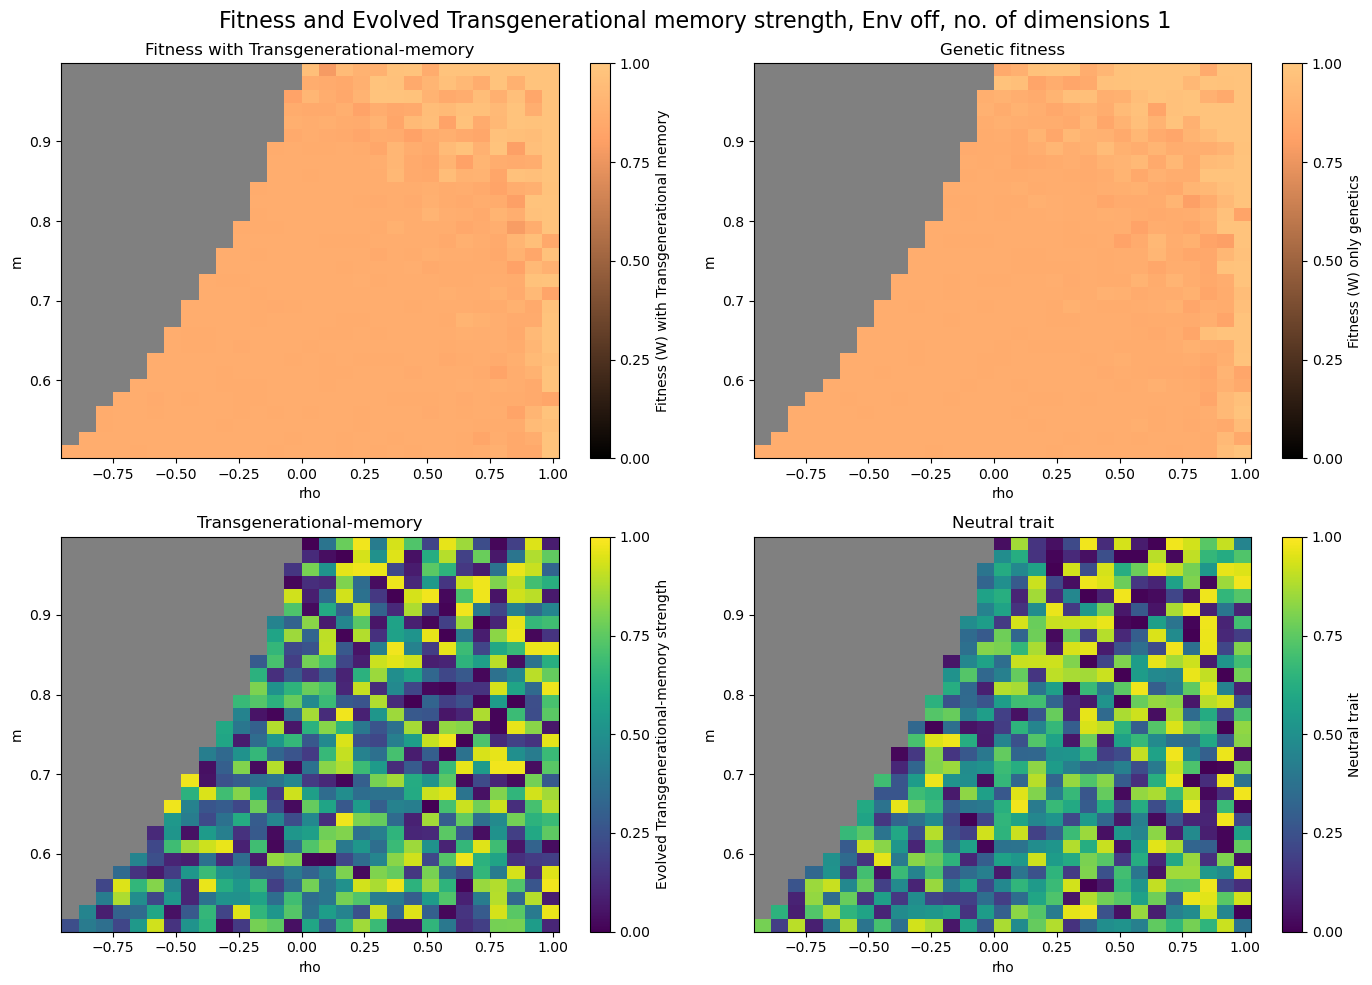

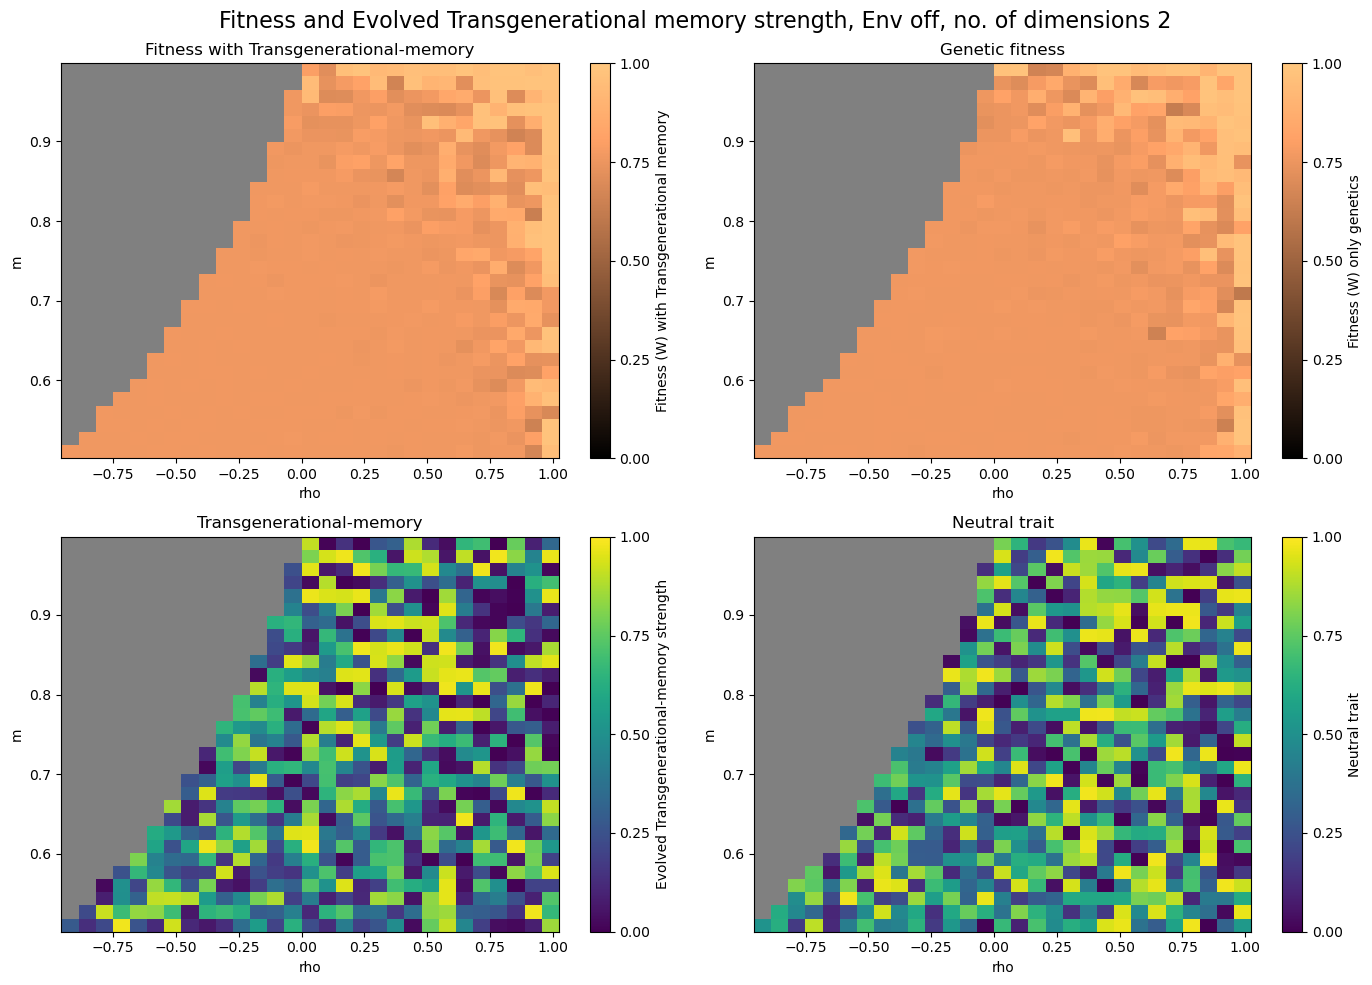

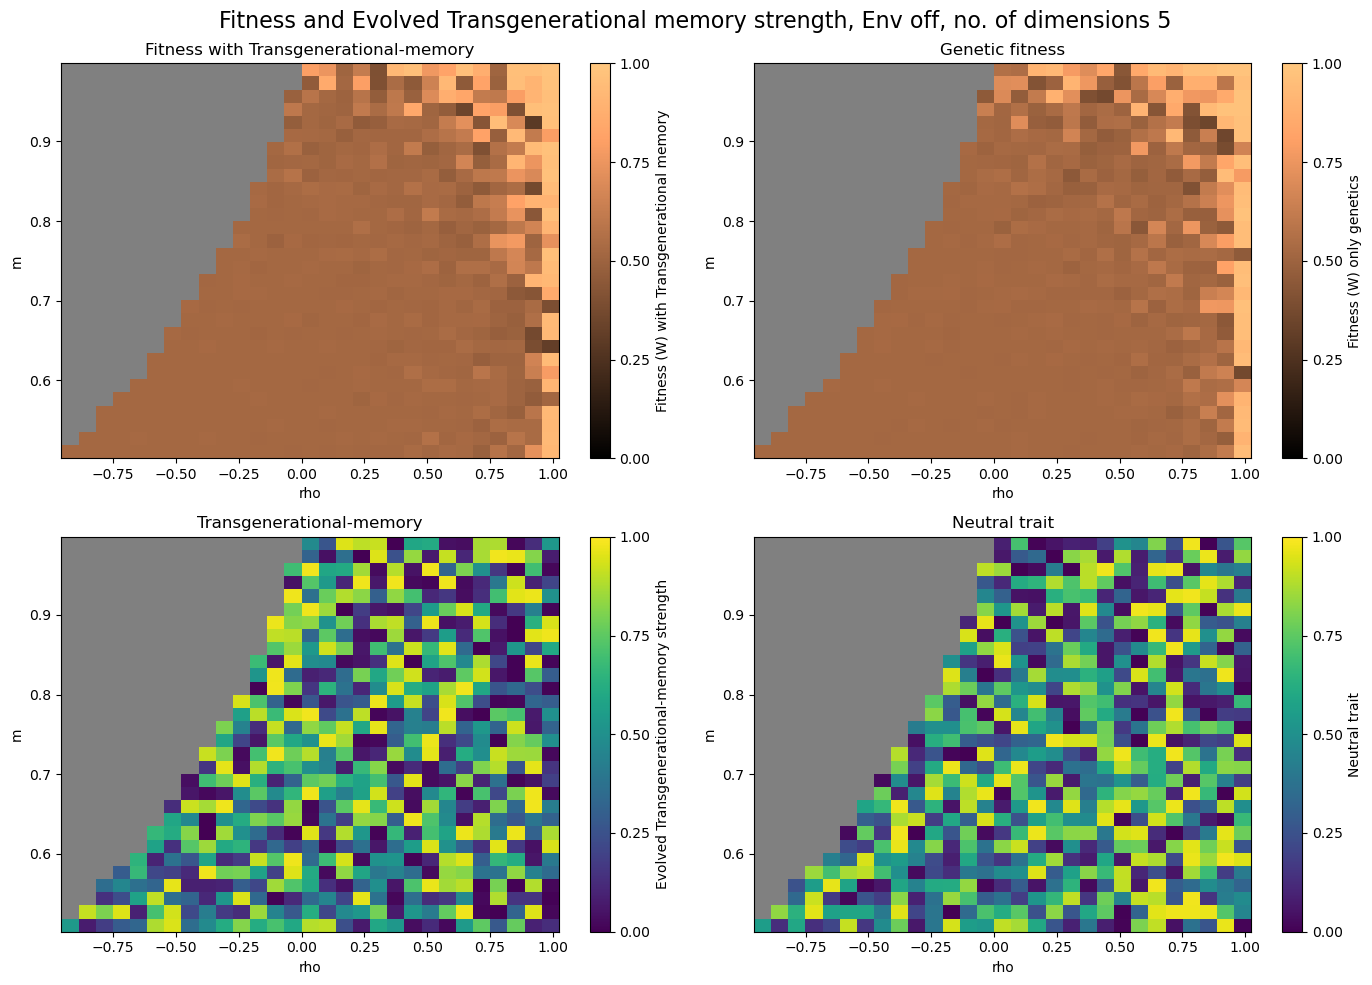

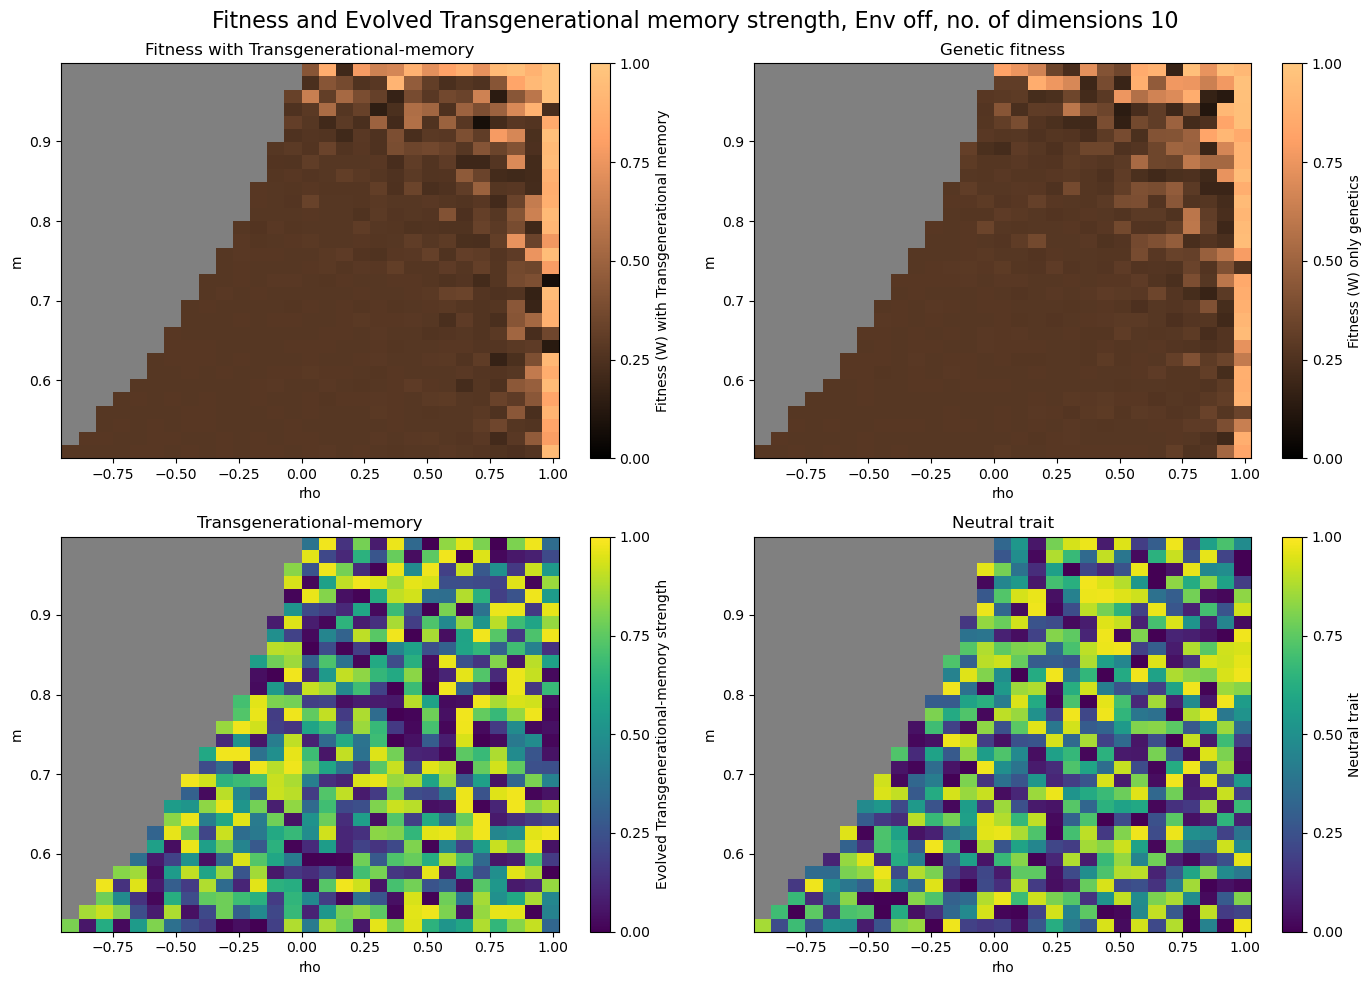

In [121]:
dims=[1,2,5,10]

for i in dims:

    concat_epi = epi_obj[f"epi_{i}"]
    concat_gen = onlygen_obj[f"gen_{i}"]   # adjust key if needed
    
    keys = list(concat_epi[0].keys())

    concatenated_results_epi = {}
    concatenated_results_gen = {}

    for k in keys:
            concatenated_results_epi[k] = np.vstack([r[k] for r in concat_epi])
            
    for k in keys:
            concatenated_results_gen[k] = np.vstack([r[k] for r in concat_gen])
            
    df_epi = pd.DataFrame({
        
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:,0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:,1],
    'fitness':np.mean(concatenated_results_epi['meanw'][:,-50:], axis=1),
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:,-50:], axis=1),
    'neutral_trait_p' : np.mean(concatenated_results_epi['meanneutral_p'][:,-50:], axis=1 ),
    
    })
    
    df_gen = pd.DataFrame({
            
        'rho': concatenated_results_gen['rho_m_alpha_beta'][:,0],
        'm': concatenated_results_gen['rho_m_alpha_beta'][:,1],
        'fitness':np.mean(concatenated_results_gen['meanw'][:,-50:], axis=1),
        })

    fig, ax = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(
        f"Fitness and Evolved Transgenerational memory strength, Env off, no. of dimensions {i}",
        fontsize=16
    )
    
    fig.subplots_adjust(top=0.90)

    cmap1 = plt.cm.copper.copy()
    cmap1.set_bad(color='gray')

    cmap2 = plt.cm.viridis.copy()
    cmap2.set_bad(color='gray')
    
    norm = mcolors.Normalize(vmin=0, vmax=1)
    
    # --- (0,0) fitness ---
    pivoted_fitness = df_epi.pivot_table(
        index='m', columns='rho', values='fitness'
    ).sort_index().sort_index(axis=1)

    pcm1 = ax[0,0].pcolormesh(
        pivoted_fitness.columns,
        pivoted_fitness.index,
        pivoted_fitness.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm1, ax=ax[0,0],
                 label='Fitness (W) with Transgenerational memory',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[0,0].set_title(r'Fitness with Transgenerational-memory')
    ax[0,0].set_ylabel('m')
    ax[0,0].set_xlabel('rho')

    # --- (0,1) genetic fitness ---
    pivoted_gen = df_gen.pivot_table(
        index='m', columns='rho', values='fitness'
    ).sort_index().sort_index(axis=1)

    pcm2 = ax[0,1].pcolormesh(
        pivoted_gen.columns,
        pivoted_gen.index,
        pivoted_gen.values,
        cmap=cmap1, norm=norm, shading='auto'
    )
    fig.colorbar(pcm2, ax=ax[0,1],
                 label='Fitness (W) only genetics',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[0,1].set_title('Genetic fitness')
    ax[0,1].set_ylabel('m')
    ax[0,1].set_xlabel('rho')

    # --- (1,0) epimem ---
    pivoted_epi = df_epi.pivot_table(
        index='m', columns='rho', values='epi_mem_p'
    ).sort_index().sort_index(axis=1)

    pcm3 = ax[1,0].pcolormesh(
        pivoted_epi.columns,
        pivoted_epi.index,
        pivoted_epi.values,
        cmap=cmap2, norm=norm, shading='auto'
    )
    fig.colorbar(pcm3, ax=ax[1,0],
                 label='Evolved Transgenerational-memory strength',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[1,0].set_title('Transgenerational-memory')
    ax[1,0].set_ylabel('m')
    ax[1,0].set_xlabel('rho')

    # --- (1,1) neutral ---
    pivoted_neutral = df_epi.pivot_table(
        index='m', columns='rho', values='neutral_trait_p'
    ).sort_index().sort_index(axis=1)

    pcm4 = ax[1,1].pcolormesh(
        pivoted_neutral.columns,
        pivoted_neutral.index,
        pivoted_neutral.values,
        cmap=cmap2, norm=norm, shading='auto'
    )
    fig.colorbar(pcm4, ax=ax[1,1],
                 label='Neutral trait',
                 ticks=[0,0.25,0.5,0.75,1.0])

    ax[1,1].set_title('Neutral trait')
    ax[1,1].set_ylabel('m')
    ax[1,1].set_xlabel('rho')

    plt.tight_layout()
    plt.show()

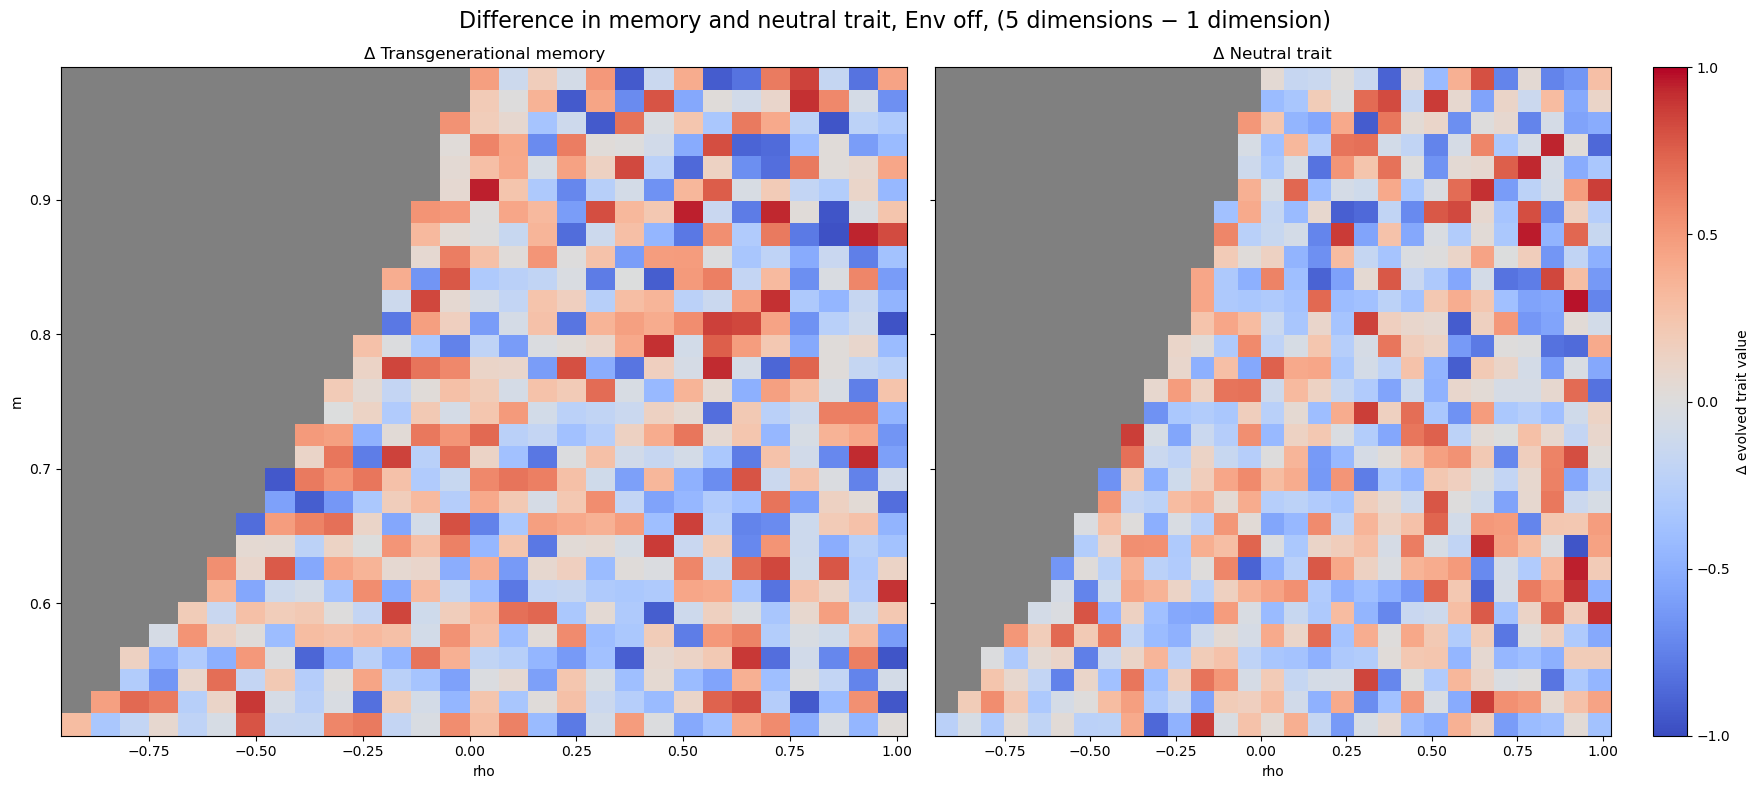

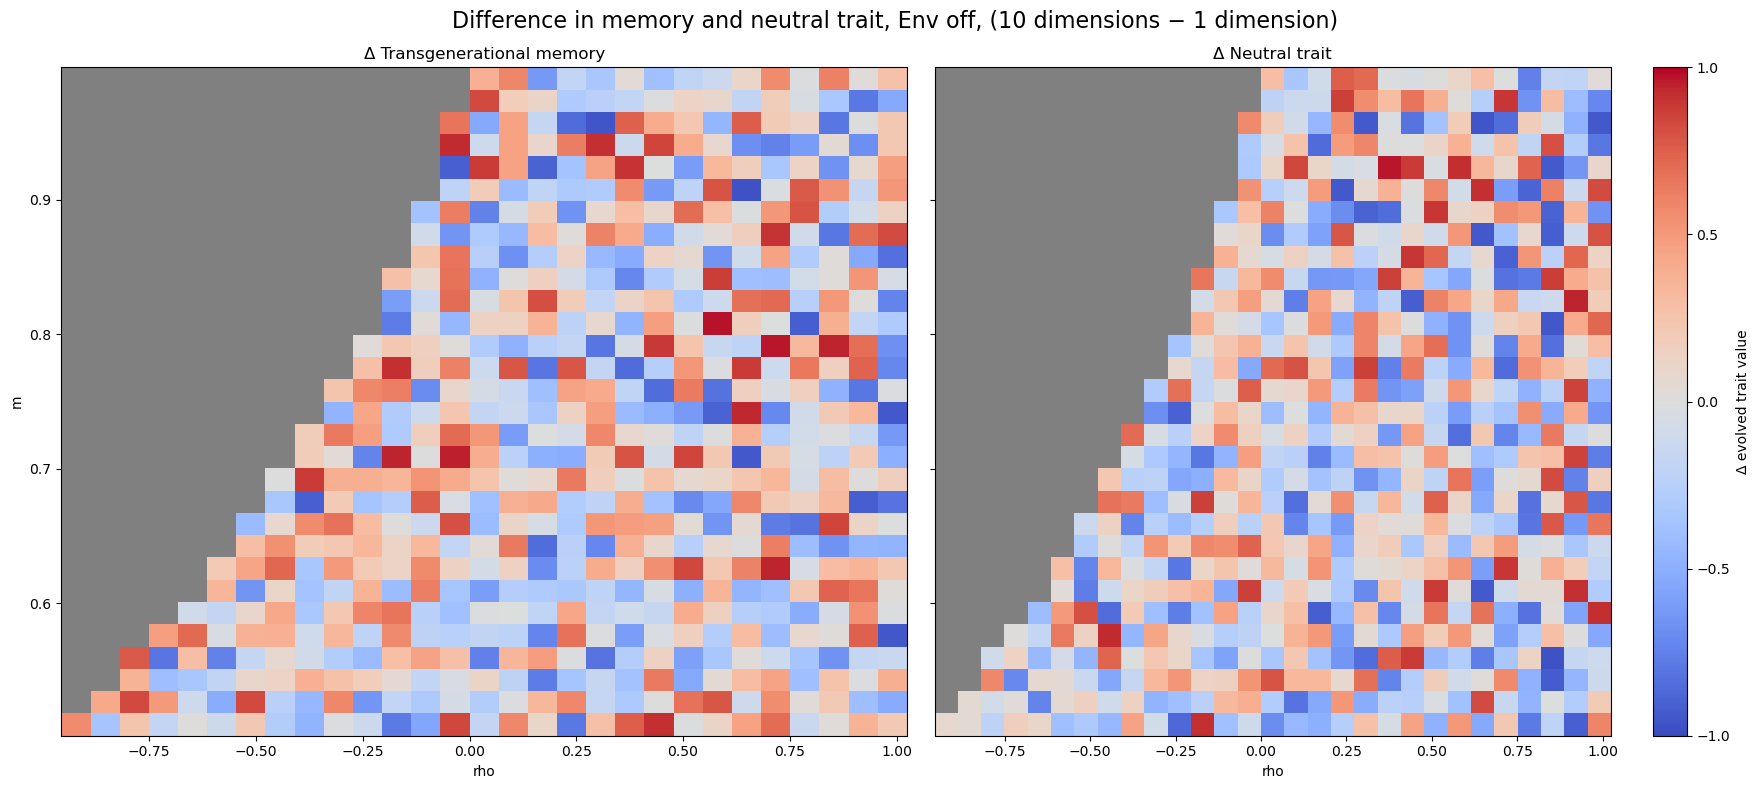

In [122]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

fig.subplots_adjust(top=0.88)

# colormap for difference
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='gray')

# symmetric normalization around 0
norm_diff = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0.0, vmax=1)

# ---------- FIRST DIMENSION (epi_1) ----------
concat_epi = epi_obj["epi_1"]
concat_gen = onlygen_obj["gen_1"]

keys = list(concat_epi[0].keys())

concatenated_results_epi = {
    k: np.vstack([r[k] for r in concat_epi]) for k in keys
}

df_epi = pd.DataFrame({
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:, 0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:, 1],
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:, -50:], axis=1),
    'neutral_trait_p': np.mean(concatenated_results_epi['meanneutral_p'][:, -50:], axis=1),
})

pivot_mem_1 = (
    df_epi.pivot_table(index='m', columns='rho', values='epi_mem_p')
    .sort_index()
    .sort_index(axis=1)
)

pivot_neutral_1 = (
    df_epi.pivot_table(index='m', columns='rho', values='neutral_trait_p')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- SECOND DIMENSION (epi_5) ----------
concat_epi = epi_obj["epi_5"]

concatenated_results_epi = {
    k: np.vstack([r[k] for r in concat_epi]) for k in keys
}

df_epi = pd.DataFrame({
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:, 0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:, 1],
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:, -50:], axis=1),
    'neutral_trait_p': np.mean(concatenated_results_epi['meanneutral_p'][:, -50:], axis=1),
})

pivot_mem_5 = (
    df_epi.pivot_table(index='m', columns='rho', values='epi_mem_p')
    .sort_index()
    .sort_index(axis=1)
)

pivot_neutral_5 = (
    df_epi.pivot_table(index='m', columns='rho', values='neutral_trait_p')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- DIFFERENCES ----------
delta_mem = pivot_mem_5 - pivot_mem_1
delta_neutral = pivot_neutral_5 - pivot_neutral_1

# ---------- PLOTS ----------
pcm0 = axes[0].pcolormesh(
    delta_mem.columns,
    delta_mem.index,
    delta_mem.values,
    cmap=cmap,
    norm=norm_diff,
    shading='auto'
)
axes[0].set_title("Δ Transgenerational memory")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("m")

pcm1 = axes[1].pcolormesh(
    delta_neutral.columns,
    delta_neutral.index,
    delta_neutral.values,
    cmap=cmap,
    norm=norm_diff,
    shading='auto'
)
axes[1].set_title("Δ Neutral trait")
axes[1].set_xlabel("rho")

# ---------- COLORBAR ----------
cbar = fig.colorbar(
    pcm0,
    ax=axes[1],
    label="Δ evolved trait value",
    ticks=[-1, -0.5, 0, 0.5, 1]
)

fig.suptitle(
    "Difference in memory and neutral trait, Env off, (5 dimensions − 1 dimension)",
    fontsize=16
)
plt.tight_layout()
plt.show()

#-------------------
#dim10-1
#-----------------


fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

fig.subplots_adjust(top=0.88)

# colormap for difference
cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='gray')

# symmetric normalization around 0
norm_diff = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0.0, vmax=1)

# ---------- FIRST DIMENSION (epi_1) ----------
concat_epi = epi_obj["epi_1"]
concat_gen = onlygen_obj["gen_1"]

keys = list(concat_epi[0].keys())

concatenated_results_epi = {
    k: np.vstack([r[k] for r in concat_epi]) for k in keys
}

df_epi = pd.DataFrame({
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:, 0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:, 1],
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:, -50:], axis=1),
    'neutral_trait_p': np.mean(concatenated_results_epi['meanneutral_p'][:, -50:], axis=1),
})

pivot_mem_1 = (
    df_epi.pivot_table(index='m', columns='rho', values='epi_mem_p')
    .sort_index()
    .sort_index(axis=1)
)

pivot_neutral_1 = (
    df_epi.pivot_table(index='m', columns='rho', values='neutral_trait_p')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- SECOND DIMENSION (epi_10) ----------
concat_epi = epi_obj["epi_10"]

concatenated_results_epi = {
    k: np.vstack([r[k] for r in concat_epi]) for k in keys
}

df_epi = pd.DataFrame({
    'rho': concatenated_results_epi['rho_m_alpha_beta'][:, 0],
    'm': concatenated_results_epi['rho_m_alpha_beta'][:, 1],
    'epi_mem_p': np.mean(concatenated_results_epi['meanmemory_p'][:, -50:], axis=1),
    'neutral_trait_p': np.mean(concatenated_results_epi['meanneutral_p'][:, -50:], axis=1),
})

pivot_mem_10 = (
    df_epi.pivot_table(index='m', columns='rho', values='epi_mem_p')
    .sort_index()
    .sort_index(axis=1)
)

pivot_neutral_10 = (
    df_epi.pivot_table(index='m', columns='rho', values='neutral_trait_p')
    .sort_index()
    .sort_index(axis=1)
)

# ---------- DIFFERENCES ----------
delta_mem = pivot_mem_10 - pivot_mem_1
delta_neutral = pivot_neutral_10 - pivot_neutral_1

# ---------- PLOTS ----------
pcm0 = axes[0].pcolormesh(
    delta_mem.columns,
    delta_mem.index,
    delta_mem.values,
    cmap=cmap,
    norm=norm_diff,
    shading='auto'
)
axes[0].set_title("Δ Transgenerational memory")
axes[0].set_xlabel("rho")
axes[0].set_ylabel("m")

pcm1 = axes[1].pcolormesh(
    delta_neutral.columns,
    delta_neutral.index,
    delta_neutral.values,
    cmap=cmap,
    norm=norm_diff,
    shading='auto'
)
axes[1].set_title("Δ Neutral trait")
axes[1].set_xlabel("rho")

# ---------- COLORBAR ----------
cbar = fig.colorbar(
    pcm0,
    ax=axes[1],
    label="Δ evolved trait value",
    ticks=[-1, -0.5, 0, 0.5, 1]
)

fig.suptitle(
    "Difference in memory and neutral trait, Env off, (10 dimensions − 1 dimension)",
    fontsize=16
)
plt.tight_layout()
plt.show()

